# Credit Worthiness Assessment
### A Loan Default Prediction Report for Lending Risk Management

---

## The Business Problem

This project builds a machine learning system that estimates the probability a borrower will default on a personal loan, using application-level data drawn from the LendingClub platform. The core mechanic is probabilistic: every prediction produces a complementary pair, `P(cannot_pay_back)` and `P(can_pay_back)`, that always sum to one. Neither output is absolute. Both are risk signals.

The fundamental error costs are asymmetric. Approving a borrower who defaults costs the lender the full principal. Rejecting a borrower who would have repaid costs only a lost interest margin. This asymmetry drives the modelling strategy: recall on the default class is the primary metric, with a business target of 88%. Missing a defaulter is the worst outcome.

Four candidate classifiers are built and compared: Logistic Regression, Random Forest, XGBoost, and LightGBM. All are tuned with Optuna on the original class-imbalanced training data, using each model's native imbalance-handling mechanism. The operating decision threshold is set from the precision-recall curve at the point that achieves the recall target — not at the statistical default of 0.5.

| Section | Topic |
|---------|-------|
| 1 | The Dataset |
| 2 | Feature Engineering |
| 3 | Exploratory Data Analysis |
| 4 | Preprocessing |
| 5 | Class Imbalance: SMOTE-ENN |
| 6 | Model Training & Comparison |
| 7 | Vintage Analysis — OCC Risk Tier Cohorts |
| 8 | Model Selection |
| 9 | Repayment Likelihood Formula |
| 10 | Results |


In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy.stats import chi2

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import LocalOutlierFactor
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    roc_curve, precision_recall_curve, f1_score, recall_score,
    average_precision_score, ConfusionMatrixDisplay, precision_score
)

from imblearn.combine import SMOTEENN
from xgboost import XGBClassifier
import lightgbm as lgb
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

import os
os.makedirs('output', exist_ok=True)

sns.set_style('whitegrid')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
print(f"numpy {np.__version__} | pandas {pd.__version__}")

numpy 2.0.2 | pandas 2.3.3


In [2]:
def compute_prg_curve(y_true, y_prob):
    """Precision-Recall Gain: PG=(p-pi)/((1-pi)*p), RG=(r-pi)/((1-pi)*r). AUPRG via trapezoid."""
    pi = y_true.mean()
    precision, recall, _ = precision_recall_curve(y_true, y_prob)
    with np.errstate(divide='ignore', invalid='ignore'):
        pg = np.where(precision > 0, (precision - pi) / ((1 - pi) * precision), 0)
        rg = np.where(recall > 0, (recall - pi) / ((1 - pi) * recall), 0)
    pg, rg = np.clip(pg, 0, 1), np.clip(rg, 0, 1)
    order = np.argsort(rg)
    return pg, rg, float(np.trapezoid(pg[order], rg[order]))

print("PRG helper defined")

PRG helper defined


## 1. The Dataset

The raw data is the LendingClub loan dataset: 9,578 personal loans with 14 features captured at the time of origination. There are no missing values. The target variable is `not.fully.paid`, renamed here to `cannot_pay_back`: 1 if the borrower defaulted, 0 if they repaid in full.

The class split is 84% repaid and 16% defaulted. This imbalance is mild by industry standards but significant enough to require explicit handling in every model. A naïve classifier that predicts "repaid" on every case would score 84% accuracy and catch zero defaulters.

Each feature maps to a question a credit officer would ask when reviewing an application.

| Feature | Underwriting Question | 5C Category |
|---|---|---|
| `purpose` | Why is the borrower taking this loan? | Character |
| `credit.policy` | Do they currently meet underwriting policy? | Character |
| `log.annual.inc` | Is their income sufficient to service the debt? | Capacity |
| `fico` | What is their credit score? | Credit History |
| `delinq.2yrs` + `pub.rec` | How bad a debtor are they historically? | Credit History |
| `dti` | How much existing debt do they carry? | Capital |
| `days.with.cr.line` | How long is their credit history? | Credit History |
| `inq.last.6mths` | How many new loans are they currently seeking? | Character |
| `int.rate` | What risk rate has the lender already assigned? | Conditions |
| `installment` + `revol.bal` + `revol.util` | What is their current debt burden? | Capital |


In [3]:
df_raw = pd.read_csv('data/loan_data.csv')
print(f"Shape: {df_raw.shape}")
print(f"Missing values: {df_raw.isnull().sum().sum()}")
df_raw.head(3)

Shape: (9578, 14)
Missing values: 0


,credit.policy,purpose,int.rate,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec,not.fully.paid
0,1,debt_consolidation,0.1189,829.10,11.350407,19.48,737,5639.958333,28854,52.1,0,0,0,0
1,1,credit_card,0.1071,228.22,11.082143,14.29,707,2760.000000,33623,76.7,0,0,0,0
2,1,debt_consolidation,0.1357,366.86,10.373491,11.63,682,4710.000000,3511,25.6,1,0,0,0


In [4]:
data_dict = {
    'purpose':           ('Why is the borrower taking this loan?',                  'Conditions'),
    'credit.policy':     ('Does the borrower meet current underwriting criteria?',   'Character'),
    'int.rate':          ('What risk rate has the lender assigned? (risk proxy)',    'Conditions'),
    'installment':       ('What is the monthly payment obligation?',                 'Capacity'),
    'log.annual.inc':    ('Is annual income sufficient to service the loan?',        'Capacity'),
    'dti':               ('What fraction of income goes to existing debt?',          'Capacity'),
    'fico':              ('What is the credit score? Maps to OCC risk tier.',        'Character'),
    'days.with.cr.line': ('How long is their credit history?',                       'Character'),
    'revol.bal':         ('What is the current revolving balance?',                  'Capital'),
    'revol.util':        ('What % of revolving credit is being used?',              'Capital'),
    'inq.last.6mths':    ('How many new loan applications in the last 6 months?',   'Conditions'),
    'delinq.2yrs':       ('How many delinquencies in the past 2 years?',            'Character'),
    'pub.rec':           ('How many bankruptcies / public records?',                'Character'),
    'not.fully.paid':    ('TARGET: Did the borrower default?',                       'Target'),
}
dict_df = pd.DataFrame([(col, q, c) for col,(q,c) in data_dict.items()],
                        columns=['Feature', 'Business Question', '5C'])
print(dict_df.to_string(index=False))

          Feature                                     Business Question         5C
          purpose                 Why is the borrower taking this loan? Conditions
    credit.policy Does the borrower meet current underwriting criteria?  Character
         int.rate  What risk rate has the lender assigned? (risk proxy) Conditions
      installment               What is the monthly payment obligation?   Capacity
   log.annual.inc      Is annual income sufficient to service the loan?   Capacity
              dti        What fraction of income goes to existing debt?   Capacity
             fico      What is the credit score? Maps to OCC risk tier.  Character
days.with.cr.line                     How long is their credit history?  Character
        revol.bal                What is the current revolving balance?    Capital
       revol.util             What % of revolving credit is being used?    Capital
   inq.last.6mths  How many new loan applications in the last 6 months? Conditions
    

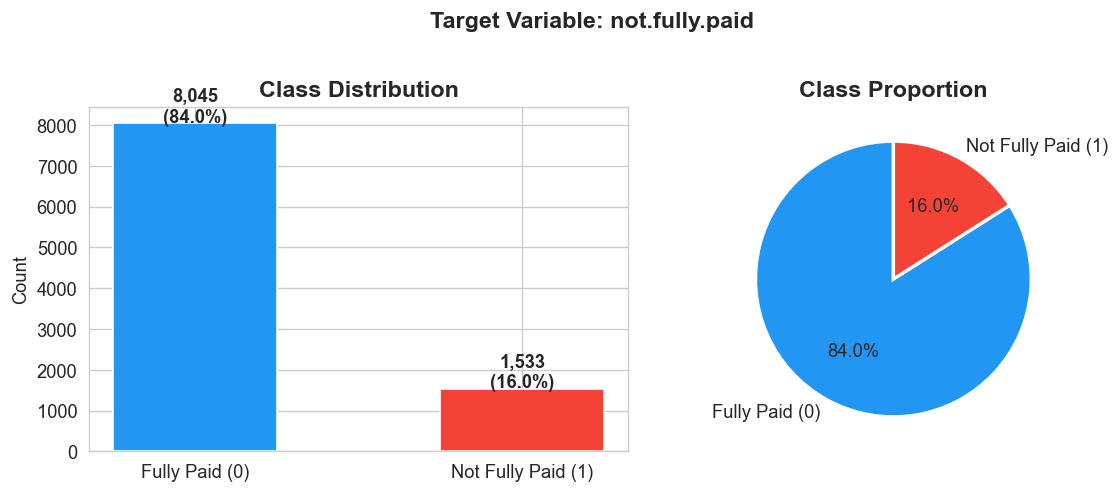

Imbalance ratio 1:5.2 — SMOTE-ENN will address this in Section 5


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
counts = df_raw['not.fully.paid'].value_counts()
labels = ['Fully Paid (0)', 'Not Fully Paid (1)']
colors = ['#2196F3', '#F44336']

axes[0].bar(labels, counts.values, color=colors, width=0.5, edgecolor='white')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 30, f'{v:,}\n({v/len(df_raw)*100:.1f}%)', ha='center', fontweight='bold')
axes[0].set_title('Class Distribution', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Count')

axes[1].pie(counts.values, labels=labels, colors=colors, autopct='%1.1f%%',
            startangle=90, wedgeprops={'edgecolor':'white','linewidth':2})
axes[1].set_title('Class Proportion', fontsize=14, fontweight='bold')

plt.suptitle('Target Variable: not.fully.paid', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('output/01_class_distribution.png', bbox_inches='tight')
plt.show()
print(f"Imbalance ratio 1:{counts[0]/counts[1]:.1f} — SMOTE-ENN will address this in Section 5")

## 2. Feature Engineering

Raw loan data does not directly express repayment capacity. This section derives regulatory-aligned features from the CFPB Ability-to-Repay rule and the OCC loan classification framework.

The most important derived feature is the Debt Service Coverage Ratio proxy: `monthly_income / installment`. A value above 1.0 means the borrower's income can cover the payment; below 1.0 means it cannot. `payment_to_income_ratio` is the inverse — the front-end DTI. Four binary flags encode regulatory thresholds: DTI above the CFPB's 43% Qualified Mortgage ceiling, revolving utilisation above 80%, any delinquency in the past two years, and any public record of default.

FICO scores are mapped to OCC loan classification tiers, which determine how supervisors expect banks to provision against each loan category.

| FICO Range | OCC Tier | Provisioning Expectation |
|---|---|---|
| < 620 | Doubtful / Loss | Full impairment likely |
| 620 – 659 | Substandard | Significant credit weakness |
| 660 – 719 | Special Mention | Potential weakness, monitor closely |
| 720+ | Pass | Adequate debt service |


In [6]:
df = df_raw.copy()
df.rename(columns={'not.fully.paid': 'cannot_pay_back'}, inplace=True)

# Capacity features (CFPB ATR / DSCR)
df['monthly_income']          = np.exp(df['log.annual.inc']) / 12
df['payment_to_income_ratio'] = df['installment'] / df['monthly_income']
df['dscr_proxy']              = df['monthly_income'] / df['installment']
df['debt_burden_annual']      = (df['installment'] * 12) / np.exp(df['log.annual.inc'])

# Regulatory flags
df['dti_flag']              = (df['dti'] > 43).astype(int)
df['high_utilization_flag'] = (df['revol.util'] > 80).astype(int)
df['delinquency_flag']      = (df['delinq.2yrs'] > 0).astype(int)
df['public_record_flag']    = (df['pub.rec'] > 0).astype(int)
df['credit_years']          = df['days.with.cr.line'] / 365

# FICO → 4 OCC risk tiers (vectorized via pd.cut)
_FICO_BINS   = [-np.inf, 620, 660, 720, np.inf]
_FICO_LABELS = ['Doubtful/Loss', 'Substandard', 'Special Mention', 'Pass']
df['occ_tier']      = pd.cut(df['fico'], bins=_FICO_BINS, labels=_FICO_LABELS, right=False).astype(str)
df['occ_tier_code'] = pd.Categorical(df['occ_tier'],
    categories=['Doubtful/Loss','Substandard','Special Mention','Pass'], ordered=True).codes

eng_cols = ['monthly_income','payment_to_income_ratio','dscr_proxy','debt_burden_annual',
            'dti_flag','high_utilization_flag','delinquency_flag','public_record_flag','credit_years']
print(df[eng_cols].describe().round(3).to_string())

       monthly_income  payment_to_income_ratio  dscr_proxy  debt_burden_annual  dti_flag  high_utilization_flag  delinquency_flag  public_record_flag  credit_years
count        9578.000                 9578.000    9578.000            9578.000    9578.0               9578.000          9578.000            9578.000      9578.000
mean         5700.169                    0.068      25.532               0.068       0.0                  0.166             0.117               0.058        12.495
std          5102.294                    0.044      37.356               0.044       0.0                  0.372             0.321               0.234         6.841
min           158.000                    0.000       1.846               0.000       0.0                  0.000             0.000               0.000         0.490
25%          3208.333                    0.035      10.967               0.035       0.0                  0.000             0.000               0.000         7.726
50%          464

In [7]:
# DSCR verification
dscr_ok  = (df['dscr_proxy'] >= 1.0).sum()
dscr_bad = (df['dscr_proxy'] < 1.0).sum()
print(f"DSCR >= 1.0 (payment coverable): {dscr_ok:,} ({dscr_ok/len(df)*100:.1f}%)")
print(f"DSCR <  1.0 (payment exceeds income): {dscr_bad:,} ({dscr_bad/len(df)*100:.1f}%)")
print(f"DTI > 43% (CFPB ceiling):   {df['dti_flag'].sum():,} ({df['dti_flag'].mean()*100:.1f}%)")
print(f"Revol. util > 80%:          {df['high_utilization_flag'].sum():,}")

print("\nOCC Tier distribution + default rate:")
tier_stats = df.groupby('occ_tier', observed=True)['cannot_pay_back'].agg(['count','mean'])
tier_stats.columns = ['n', 'default_rate']
tier_stats['default_rate'] = tier_stats['default_rate'].map('{:.1%}'.format)
print(tier_stats.to_string())

DSCR >= 1.0 (payment coverable): 9,578 (100.0%)
DSCR <  1.0 (payment exceeds income): 0 (0.0%)
DTI > 43% (CFPB ceiling):   0 (0.0%)
Revol. util > 80%:          1,589

OCC Tier distribution + default rate:
                    n default_rate
occ_tier                          
Doubtful/Loss       3        33.3%
Pass             3622        10.3%
Special Mention  5467        18.4%
Substandard       486        30.9%


## 3. Exploratory Data Analysis

Before any modelling, the data needs to be understood on its own terms. This section covers four questions in sequence: how individual features are distributed, how they relate to each other and to the default outcome, whether the dataset contains anomalous observations that could distort model training, and whether borrowers naturally cluster into distinct risk segments.

The EDA findings directly inform every preprocessing decision in Section 4. No step in that section is arbitrary.


### 3.1 Univariate Analysis

A histogram and KDE for each numeric feature, followed by category counts for `purpose`, OCC tier, and credit policy. The goal is to identify skew, concentration, and any obvious anomalies before looking at relationships between features.


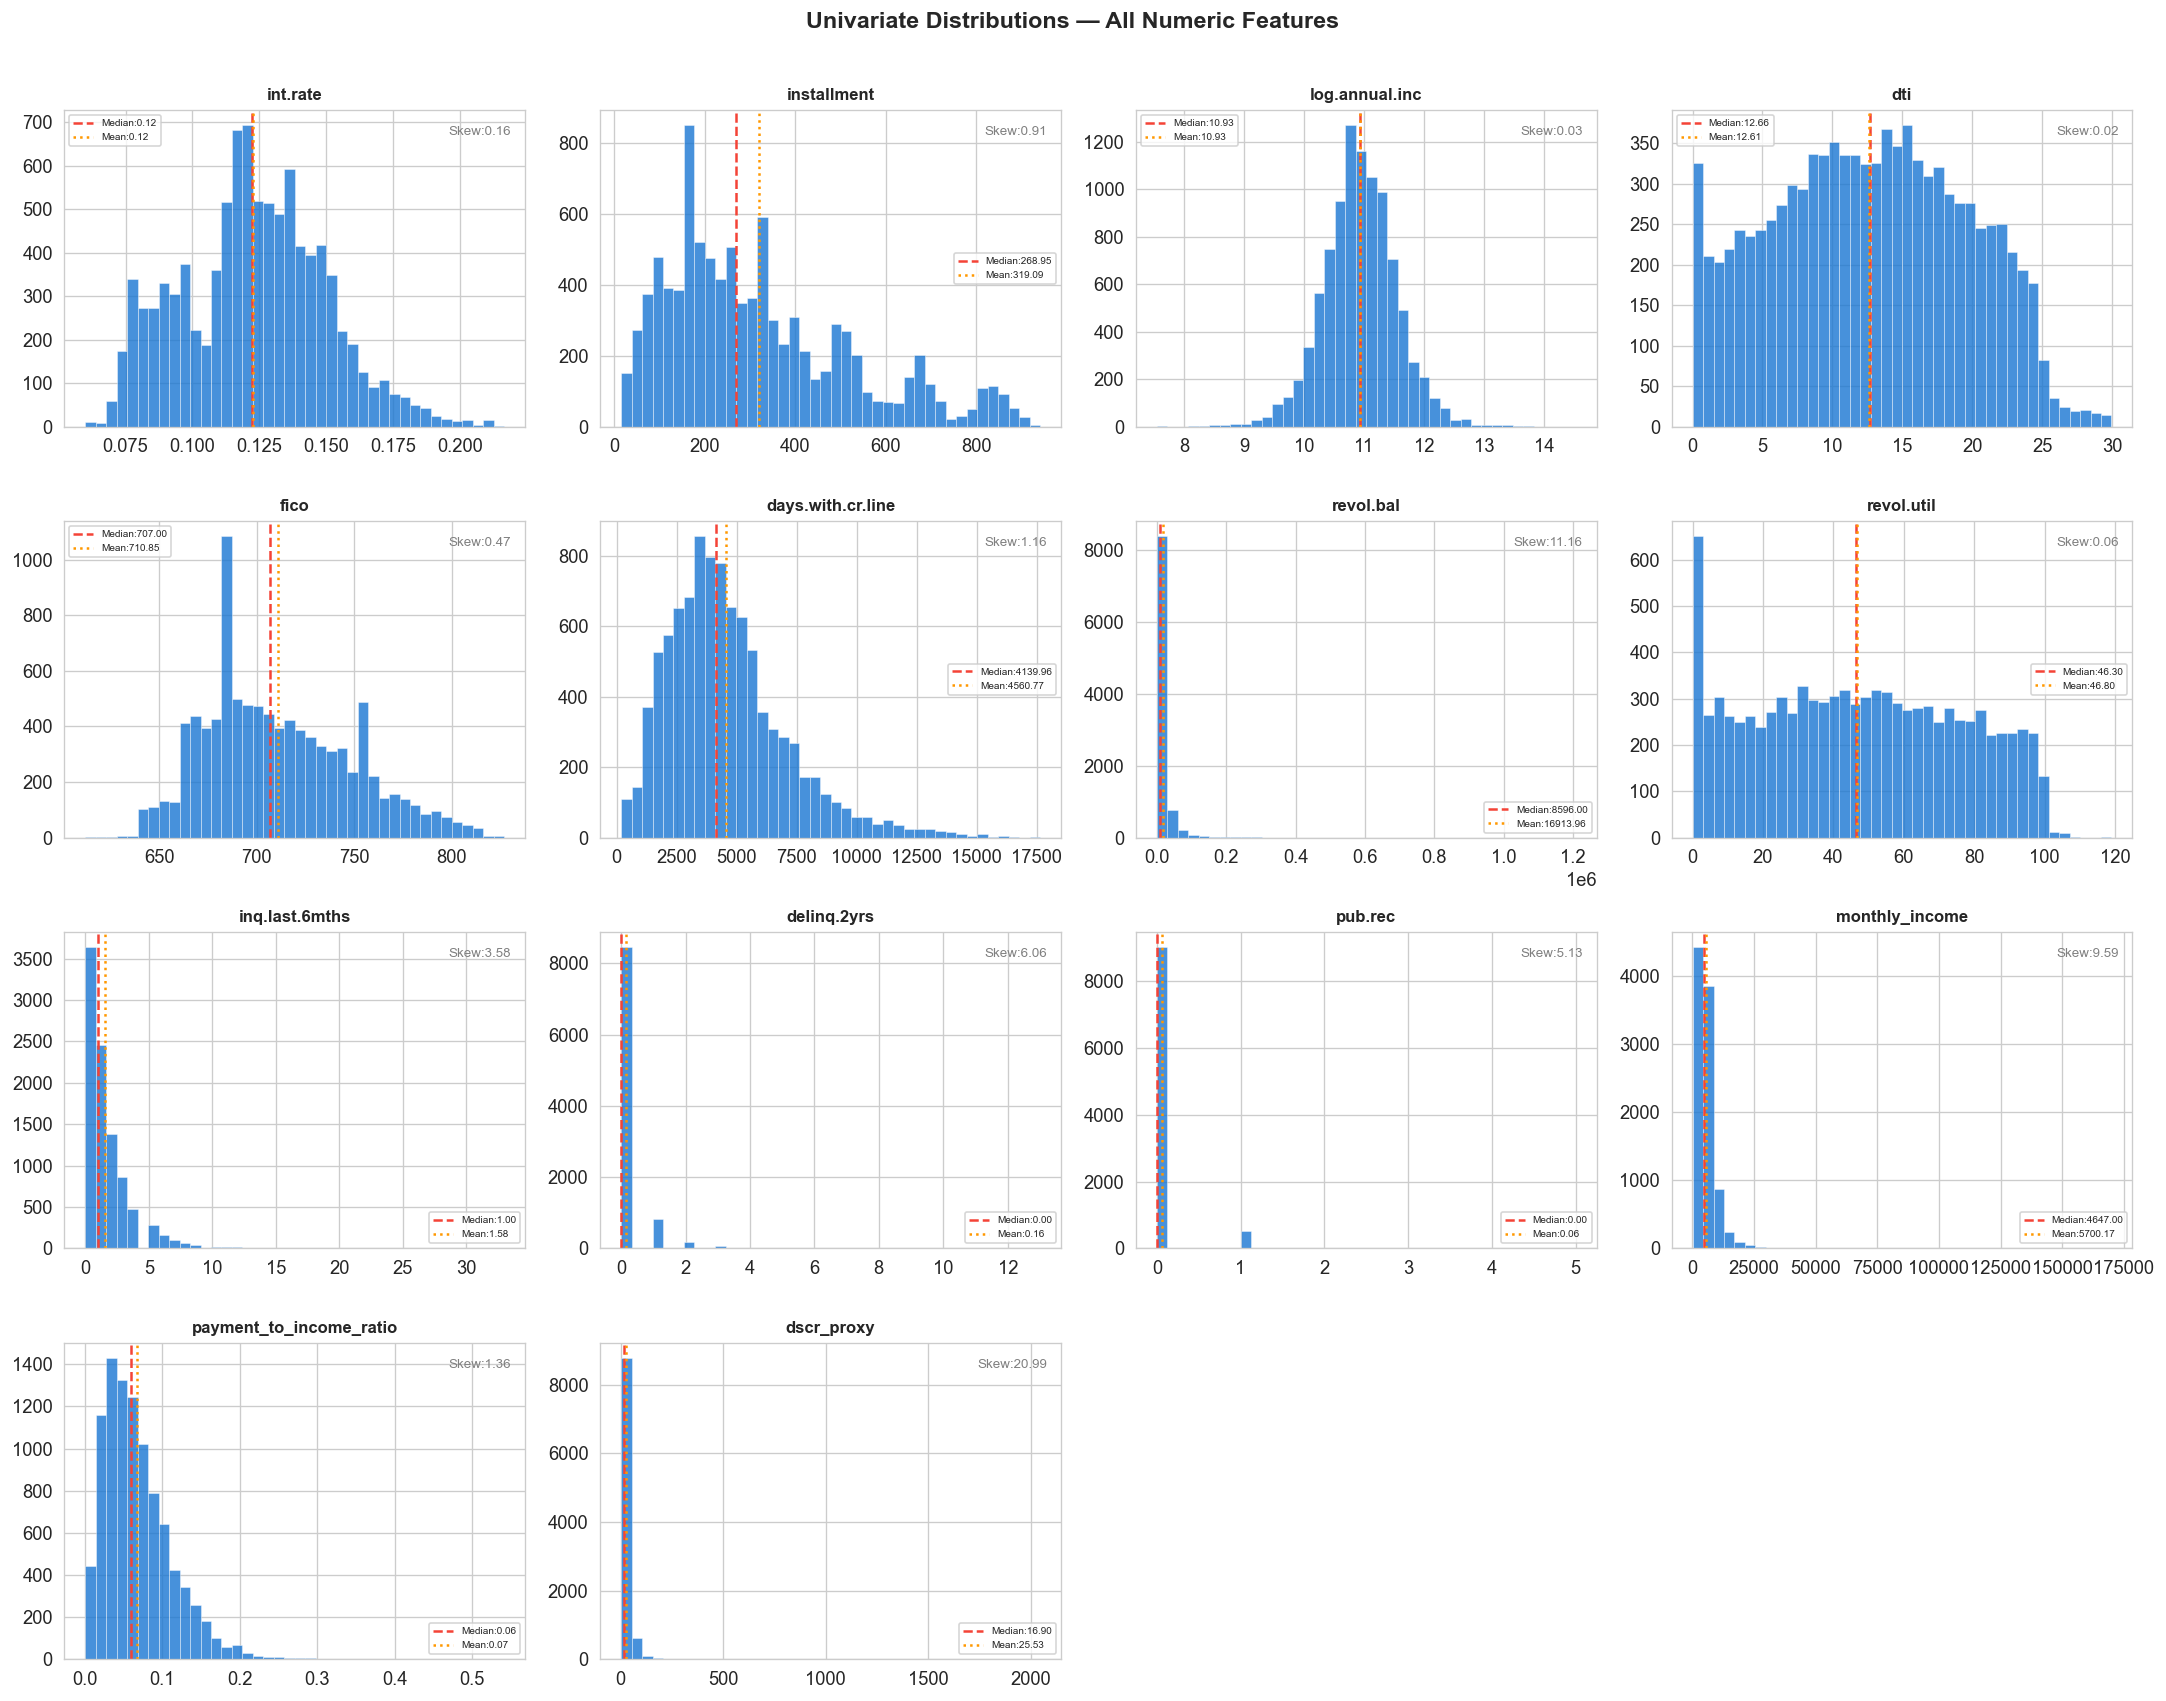

In [8]:
numeric_cols = ['int.rate','installment','log.annual.inc','dti','fico',
                'days.with.cr.line','revol.bal','revol.util','inq.last.6mths',
                'delinq.2yrs','pub.rec','monthly_income','payment_to_income_ratio','dscr_proxy']

fig, axes = plt.subplots(4, 4, figsize=(18, 14))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    data = df[col].dropna()
    axes[i].hist(data, bins=40, color='#1976D2', alpha=0.8, edgecolor='white', linewidth=0.3)
    axes[i].axvline(data.median(), color='#F44336', linestyle='--', lw=1.5,
                    label=f'Median:{data.median():.2f}')
    axes[i].axvline(data.mean(),   color='#FF9800', linestyle=':',  lw=1.5,
                    label=f'Mean:{data.mean():.2f}')
    axes[i].set_title(col, fontsize=10, fontweight='bold')
    axes[i].text(0.97, 0.95, f'Skew:{data.skew():.2f}', transform=axes[i].transAxes,
                 ha='right', va='top', fontsize=8, color='gray')
    axes[i].legend(fontsize=6)

for j in range(len(numeric_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Univariate Distributions — All Numeric Features', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('output/02_univariate_numeric.png', bbox_inches='tight')
plt.show()

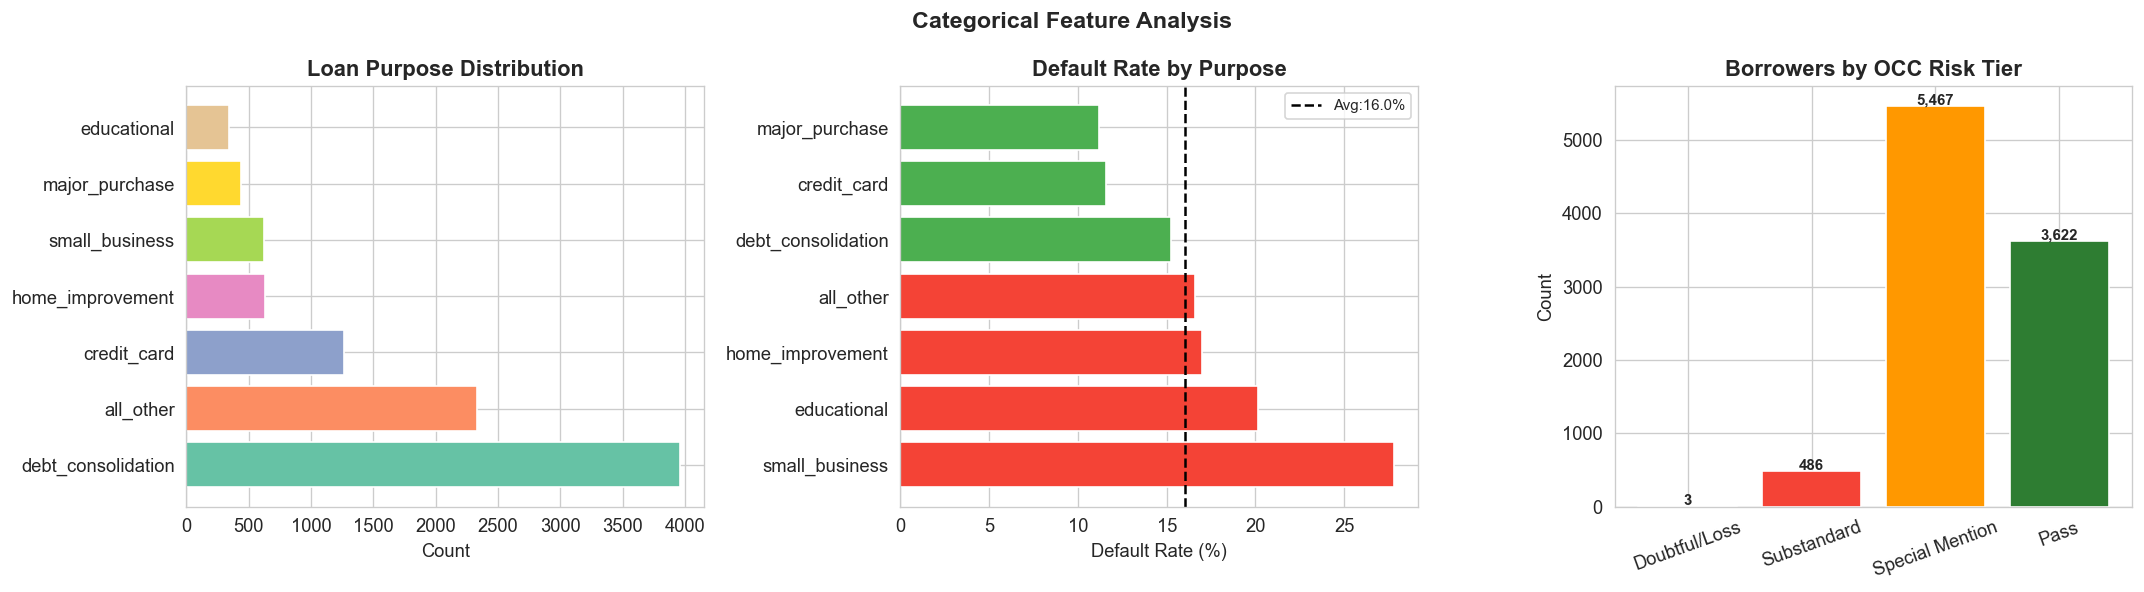

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Purpose counts
purpose_counts = df['purpose'].value_counts()
axes[0].barh(purpose_counts.index, purpose_counts.values,
             color=sns.color_palette('Set2', len(purpose_counts)))
axes[0].set_title('Loan Purpose Distribution', fontweight='bold')
axes[0].set_xlabel('Count')

# Default rate by purpose
purpose_dr = df.groupby('purpose')['cannot_pay_back'].mean().sort_values(ascending=False)
overall_dr = df['cannot_pay_back'].mean()
axes[1].barh(purpose_dr.index,
             purpose_dr.values * 100,
             color=['#F44336' if v > overall_dr else '#4CAF50' for v in purpose_dr.values])
axes[1].axvline(overall_dr * 100, color='black', linestyle='--', lw=1.5, label=f'Avg:{overall_dr*100:.1f}%')
axes[1].set_title('Default Rate by Purpose', fontweight='bold')
axes[1].set_xlabel('Default Rate (%)')
axes[1].legend(fontsize=9)

# OCC tier distribution
tier_order  = ['Doubtful/Loss','Substandard','Special Mention','Pass']
tier_colors = ['#B71C1C','#F44336','#FF9800','#2E7D32']
tier_n = df['occ_tier'].value_counts().reindex(tier_order)
axes[2].bar(tier_order, tier_n.values, color=tier_colors, edgecolor='white')
for i, v in enumerate(tier_n.values):
    axes[2].text(i, v + 20, f'{v:,}', ha='center', fontsize=9, fontweight='bold')
axes[2].set_title('Borrowers by OCC Risk Tier', fontweight='bold')
axes[2].set_ylabel('Count')
axes[2].tick_params(axis='x', rotation=20)

plt.suptitle('Categorical Feature Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('output/03_categorical_analysis.png', bbox_inches='tight')
plt.show()

### 3.2 Multivariate Analysis

Four views of how features relate to each other and to the default outcome. The correlation heatmap identifies collinear pairs. Box plots and violin plots show how each feature's distribution shifts between borrowers who repaid and those who defaulted. The purpose breakdown reveals which loan categories carry the highest default rates — a signal that underwriting criteria may need to differ by product type.


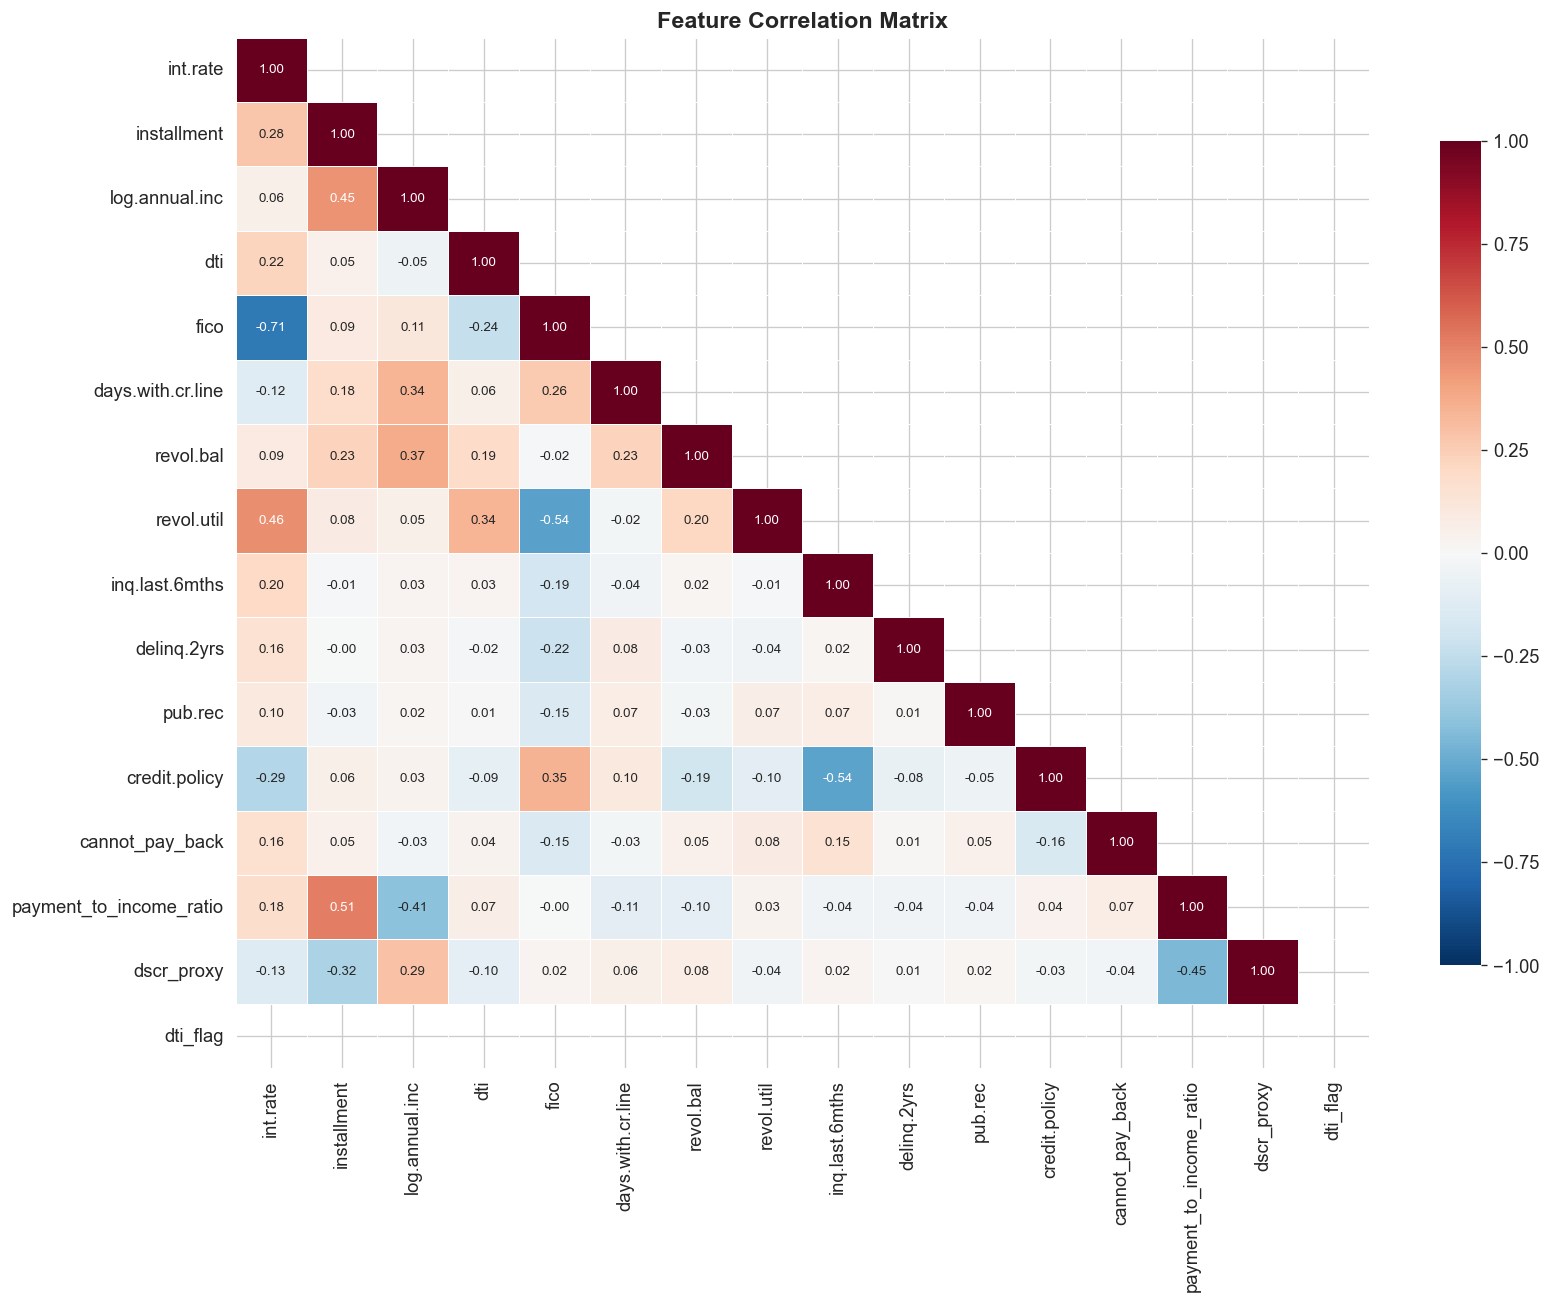

Top correlations with cannot_pay_back:
int.rate                   0.160
credit.policy             -0.158
fico                      -0.150
inq.last.6mths             0.149
revol.util                 0.082
payment_to_income_ratio    0.074
revol.bal                  0.054
installment                0.050
pub.rec                    0.049
dscr_proxy                -0.038


In [10]:
# Correlation heatmap
numeric_feats = ['int.rate','installment','log.annual.inc','dti','fico',
                 'days.with.cr.line','revol.bal','revol.util','inq.last.6mths',
                 'delinq.2yrs','pub.rec','credit.policy','cannot_pay_back',
                 'payment_to_income_ratio','dscr_proxy','dti_flag']

corr = df[numeric_feats].corr()
fig, ax = plt.subplots(figsize=(14, 11))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, ax=ax, linewidths=0.5,
            cbar_kws={'shrink':0.8}, annot_kws={'size':8})
ax.set_title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('output/04_correlation_heatmap.png', bbox_inches='tight')
plt.show()

target_corr = corr['cannot_pay_back'].drop('cannot_pay_back').sort_values(key=abs, ascending=False)
print("Top correlations with cannot_pay_back:")
print(target_corr.head(10).round(3).to_string())

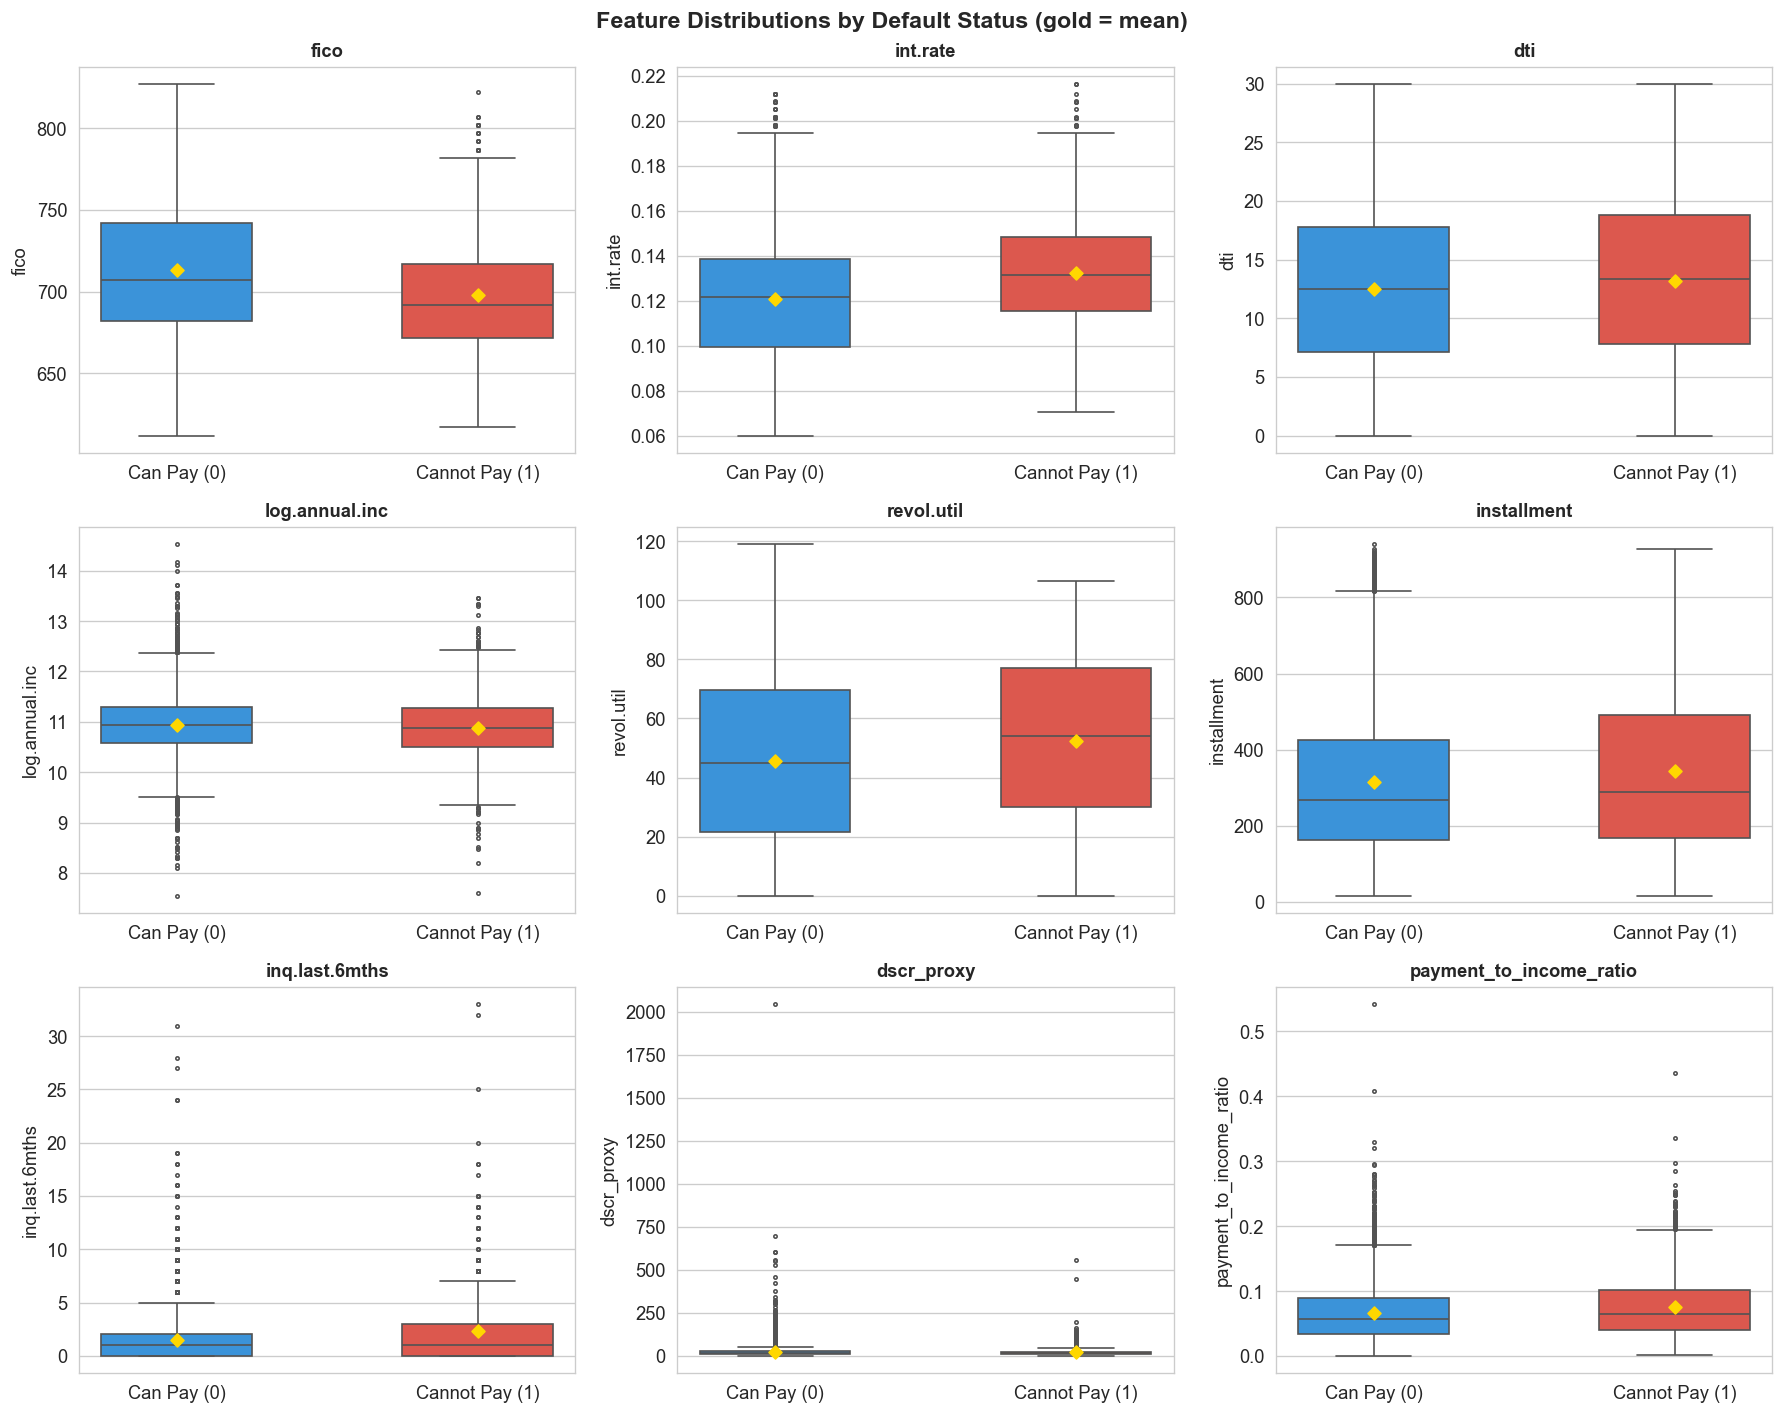

In [11]:
# Box plots — precompute group means once (O(N)), not per-feature (O(9N))
key_features = ['fico','int.rate','dti','log.annual.inc','revol.util',
                'installment','inq.last.6mths','dscr_proxy','payment_to_income_ratio']
_target_means = df.groupby('cannot_pay_back')[key_features].mean()

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()
for i, col in enumerate(key_features):
    sns.boxplot(data=df, x='cannot_pay_back', y=col, palette=['#2196F3','#F44336'],
                ax=axes[i], width=0.5, fliersize=2)
    axes[i].set_xticklabels(['Can Pay (0)', 'Cannot Pay (1)'])
    axes[i].set_title(col, fontsize=11, fontweight='bold')
    axes[i].set_xlabel('')
    for k in [0, 1]:
        axes[i].scatter(k, _target_means.loc[k, col], marker='D', color='gold', s=30, zorder=5)

plt.suptitle('Feature Distributions by Default Status (gold = mean)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('output/05_boxplots_by_target.png', bbox_inches='tight')
plt.show()

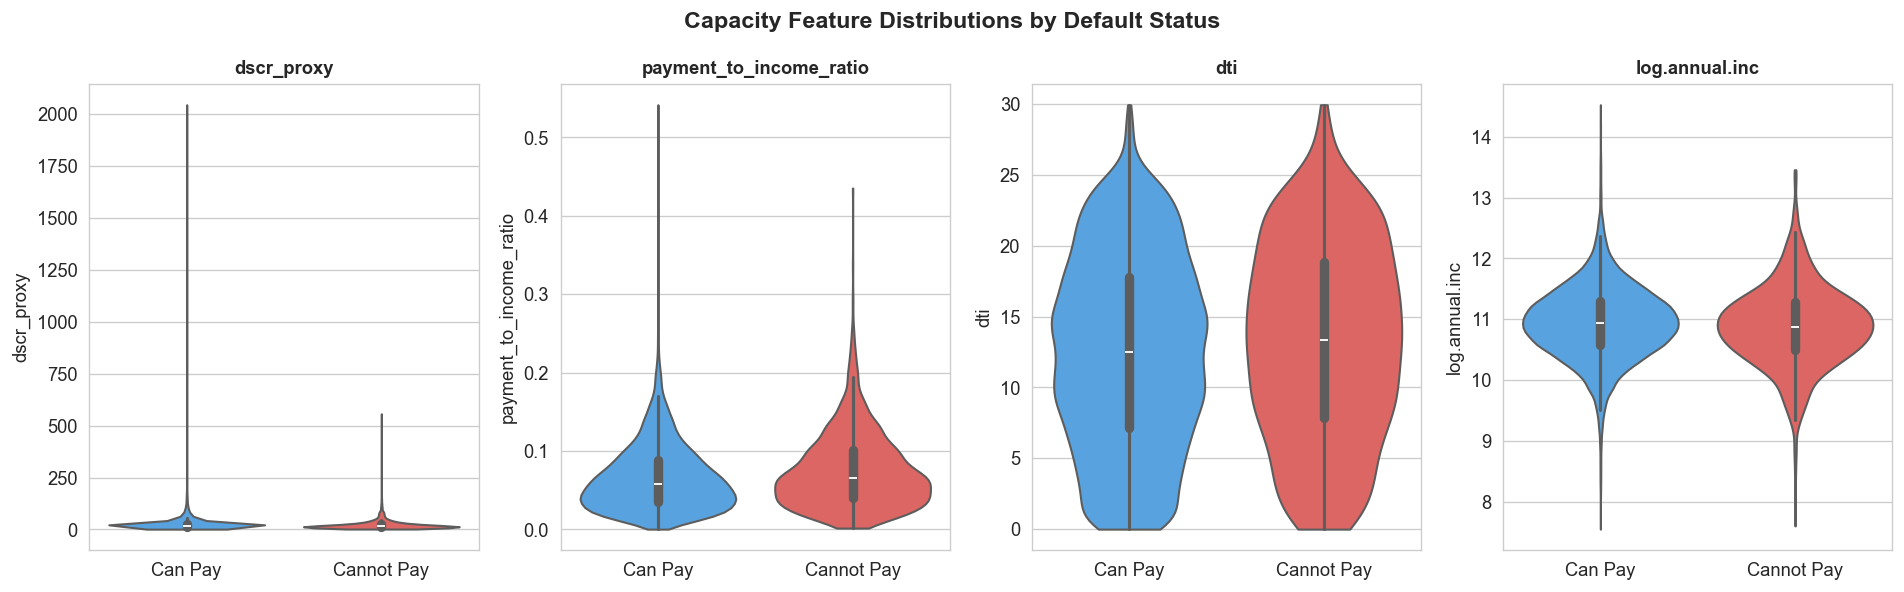

In [12]:
# Violin plots — capacity features
capacity_feats = ['dscr_proxy','payment_to_income_ratio','dti','log.annual.inc']
fig, axes = plt.subplots(1, 4, figsize=(16, 5))
for i, col in enumerate(capacity_feats):
    sns.violinplot(data=df, x='cannot_pay_back', y=col, palette=['#42A5F5','#EF5350'],
                   ax=axes[i], inner='box', cut=0)
    axes[i].set_xticklabels(['Can Pay','Cannot Pay'])
    axes[i].set_title(col, fontsize=11, fontweight='bold')
    axes[i].set_xlabel('')

plt.suptitle('Capacity Feature Distributions by Default Status', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('output/06_violin_capacity.png', bbox_inches='tight')
plt.show()

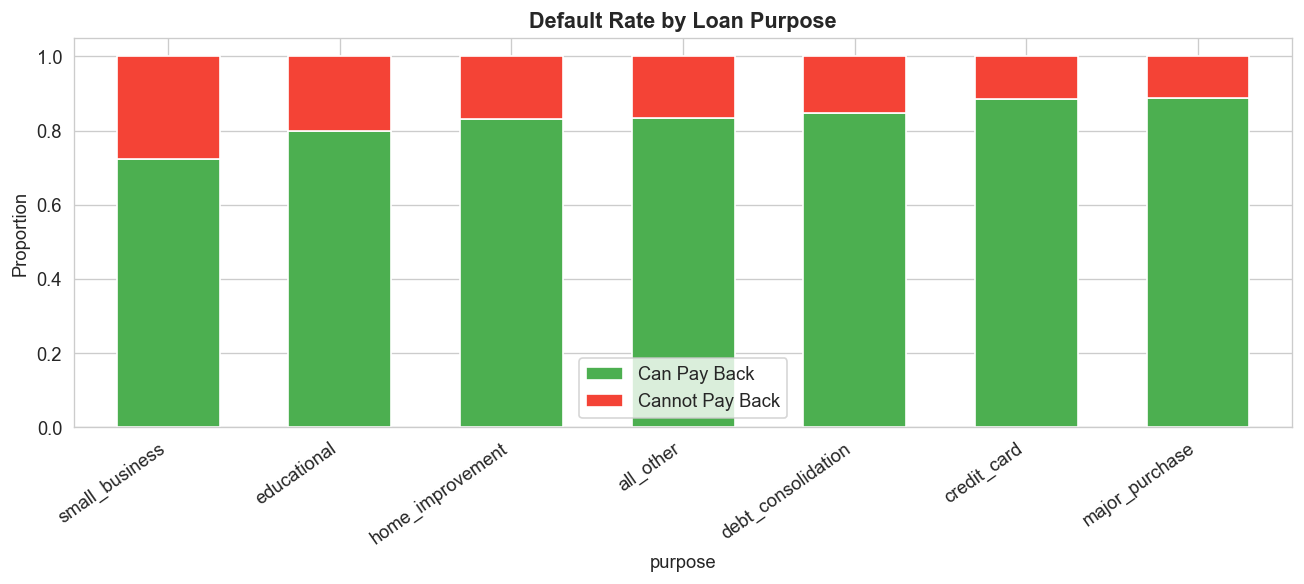

In [13]:
# Purpose default rate stacked bar
purpose_grouped = df.groupby('purpose')['cannot_pay_back'].value_counts(normalize=True).unstack().fillna(0)
purpose_grouped = purpose_grouped.sort_values(1, ascending=False)

fig, ax = plt.subplots(figsize=(11, 5))
purpose_grouped[[0,1]].plot(kind='bar', stacked=True, ax=ax,
    color=['#4CAF50','#F44336'], edgecolor='white', width=0.6)
ax.set_xticklabels(purpose_grouped.index, rotation=35, ha='right')
ax.set_ylabel('Proportion')
ax.set_title('Default Rate by Loan Purpose', fontsize=13, fontweight='bold')
ax.legend(['Can Pay Back','Cannot Pay Back'])
plt.tight_layout()
plt.savefig('output/07_purpose_stacked.png', bbox_inches='tight')
plt.show()

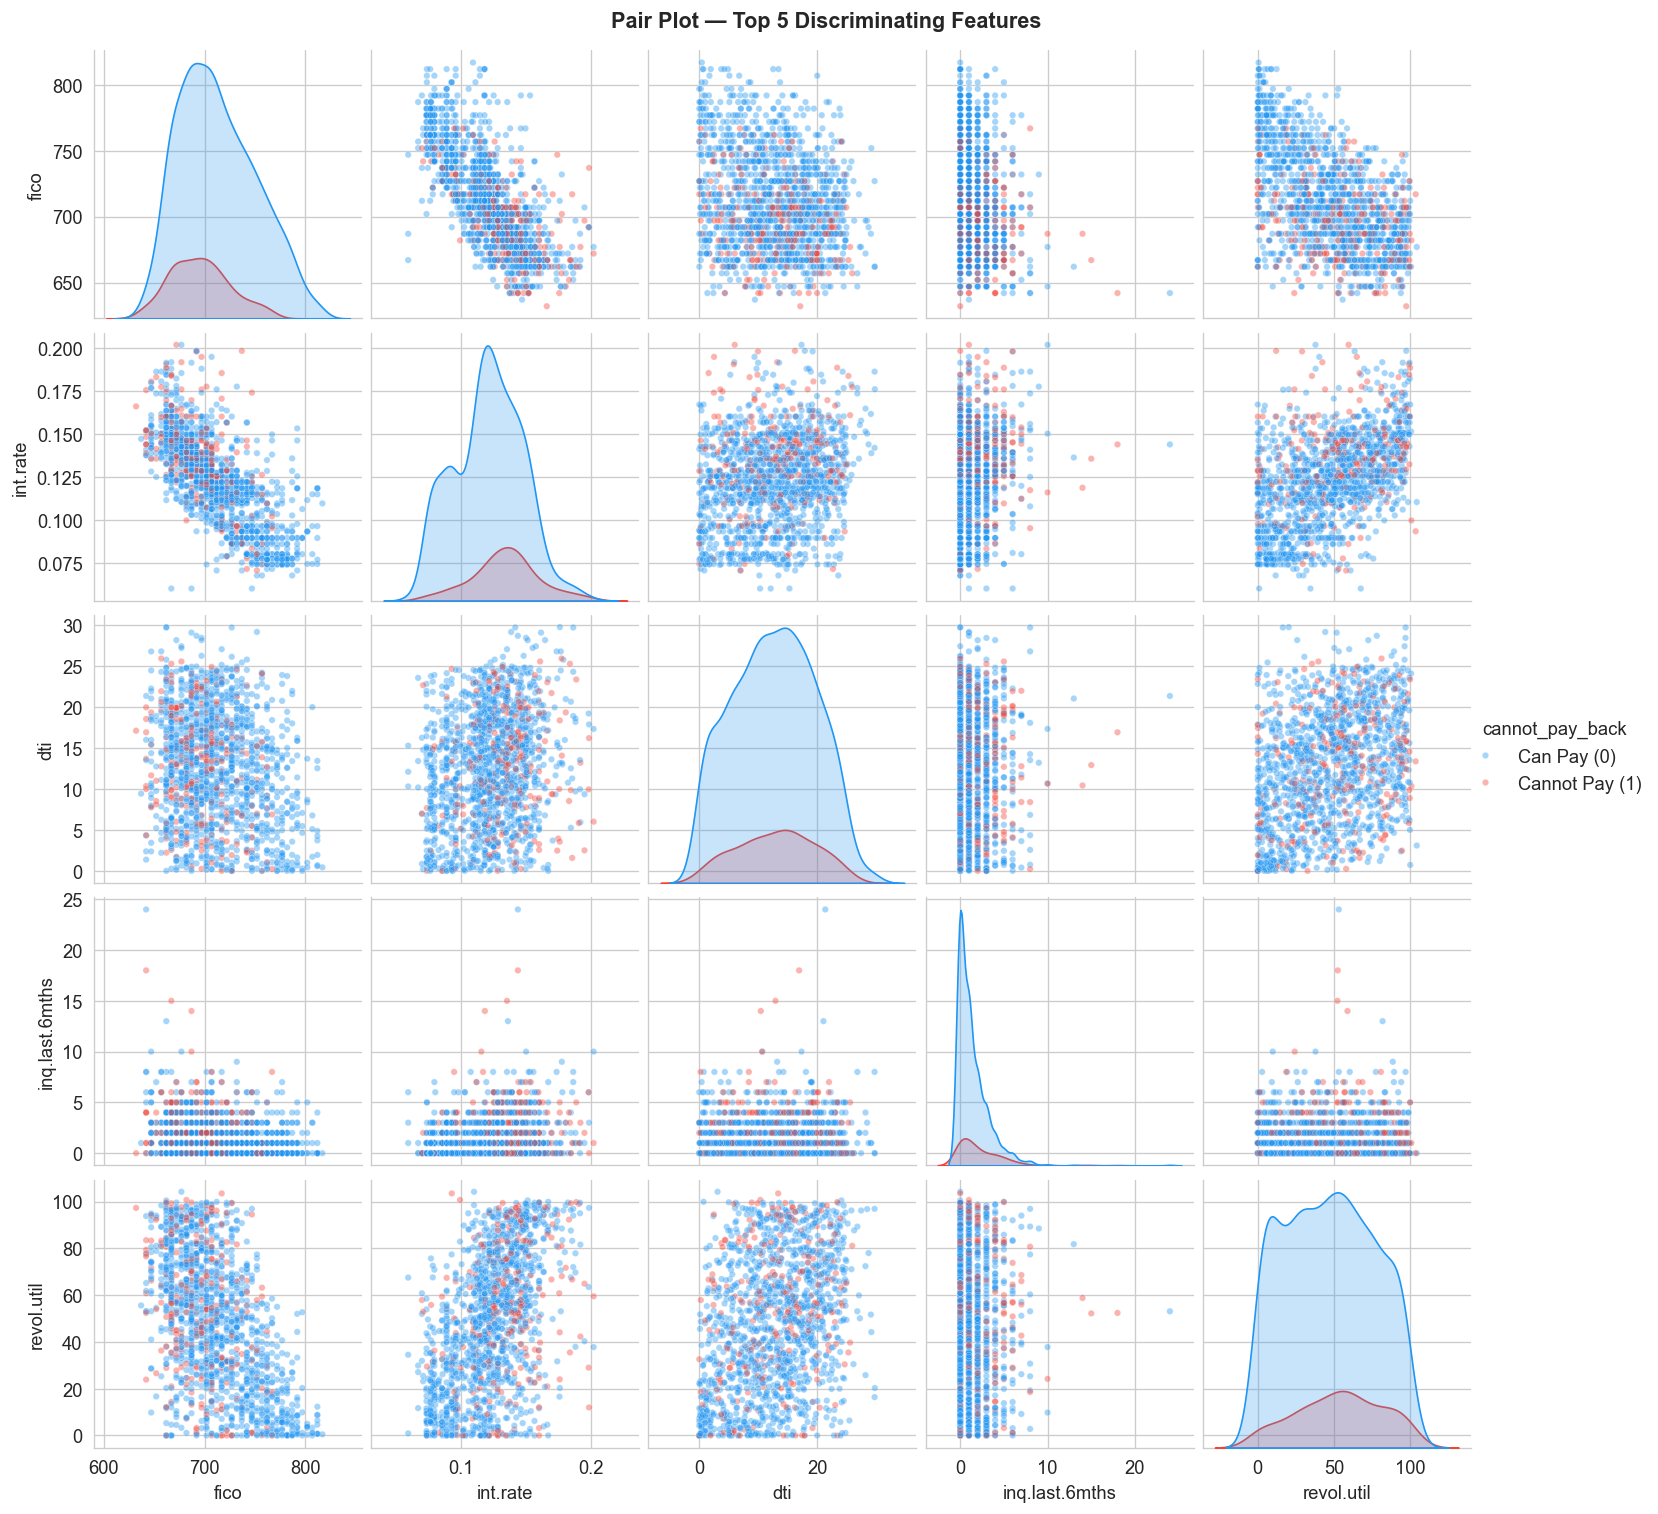

In [14]:
# Pair plot — top 5 discriminating features (sampled for speed)
top5 = ['fico','int.rate','dti','inq.last.6mths','revol.util']
pair_df = df[top5 + ['cannot_pay_back']].sample(1500, random_state=RANDOM_STATE)
g = sns.pairplot(pair_df, hue='cannot_pay_back', palette=['#2196F3','#F44336'],
                 diag_kind='kde', plot_kws={'alpha':0.4,'s':15}, hue_order=[0,1])
g.fig.suptitle('Pair Plot — Top 5 Discriminating Features', y=1.01, fontsize=13, fontweight='bold')
for t, l in zip(g._legend.texts, ['Can Pay (0)','Cannot Pay (1)']):
    t.set_text(l)
plt.savefig('output/08_pairplot.png', bbox_inches='tight')
plt.show()

### 3.3 Outlier Detection

Two independent methods are applied to the numeric feature space. Local Outlier Factor detects points that are anomalous relative to their local neighbourhood — borrowers whose combination of features is unlike anyone nearby. Mahalanobis distance detects points that are anomalous in the global multivariate sense — borrowers far from the centroid when all feature correlations are accounted for.

Both methods flag observations for review but do not remove them. The flagged borrowers are retained in the dataset. Removing them would discard real edge cases present in the borrower population. Their flags are treated as features and later dropped at the preprocessing stage after EDA confirms they add no predictive signal beyond what FICO and DTI already capture.


LOF outliers: 479 (5.0%) — retained, not dropped
Default rate in LOF outliers: 25.7%
Default rate in inliers:      15.5%


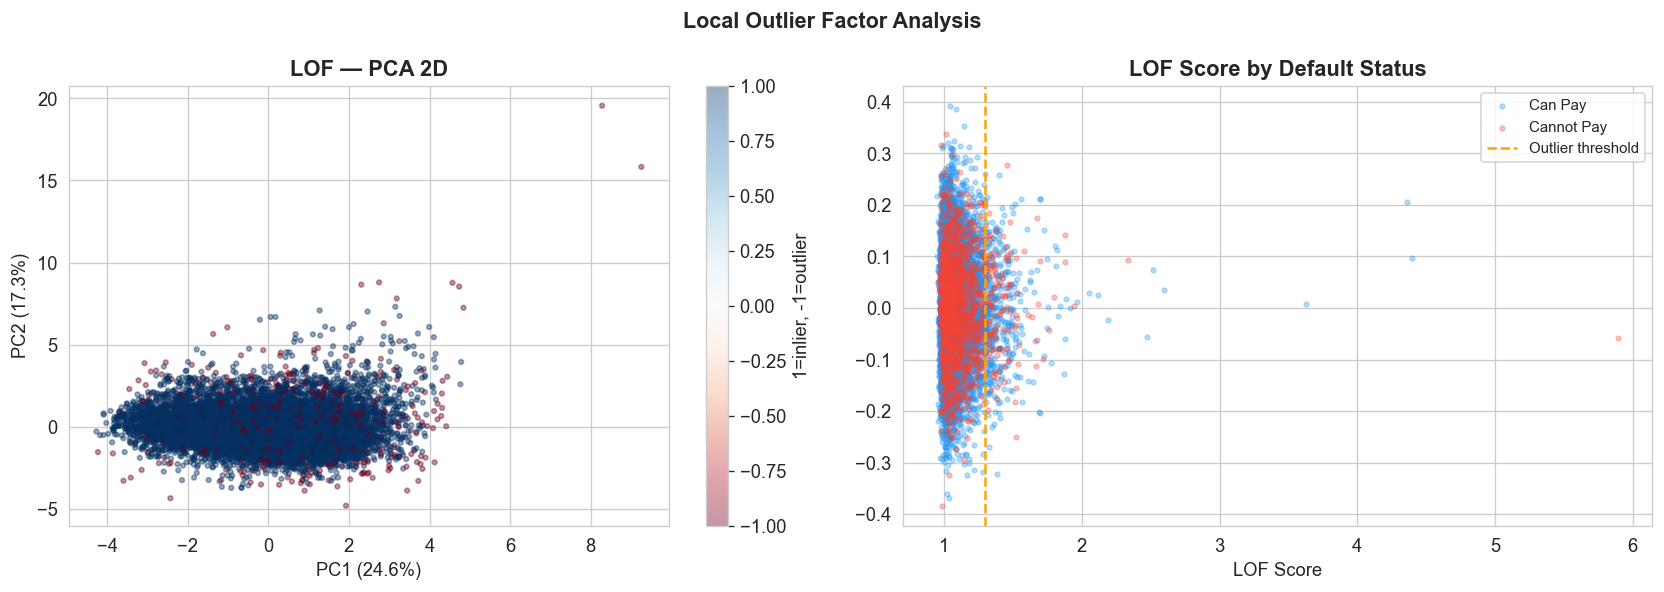

In [15]:
numeric_for_outliers = ['int.rate','installment','log.annual.inc','dti','fico',
                        'revol.bal','revol.util','inq.last.6mths','delinq.2yrs','pub.rec']

scaler_lof = StandardScaler()
X_lof = scaler_lof.fit_transform(df[numeric_for_outliers].fillna(df[numeric_for_outliers].median()))

lof = LocalOutlierFactor(n_neighbors=20, contamination=0.05)
lof_labels = lof.fit_predict(X_lof)
lof_scores = -lof.negative_outlier_factor_
df['lof_flag'] = (lof_labels == -1).astype(int)
n_lof = df['lof_flag'].sum()
print(f"LOF outliers: {n_lof} ({n_lof/len(df)*100:.1f}%) — retained, not dropped")
print(f"Default rate in LOF outliers: {df.loc[df['lof_flag']==1,'cannot_pay_back'].mean():.1%}")
print(f"Default rate in inliers:      {df.loc[df['lof_flag']==0,'cannot_pay_back'].mean():.1%}")

pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_lof)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sc = axes[0].scatter(X_pca[:,0], X_pca[:,1], c=lof_labels, cmap='RdBu', alpha=0.4, s=8)
axes[0].set_title('LOF — PCA 2D', fontweight='bold')
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
plt.colorbar(sc, ax=axes[0], label='1=inlier, -1=outlier')

for t, color, label in [(0,'#2196F3','Can Pay'), (1,'#F44336','Cannot Pay')]:
    m = df['cannot_pay_back'] == t
    axes[1].scatter(lof_scores[m], np.random.randn(m.sum())*0.1,
                    c=color, alpha=0.3, s=8, label=label)
axes[1].axvline(lof_scores[lof_labels==-1].min(), color='orange',
                linestyle='--', label='Outlier threshold')
axes[1].set_xlabel('LOF Score')
axes[1].set_title('LOF Score by Default Status', fontweight='bold')
axes[1].legend(fontsize=9)
plt.suptitle('Local Outlier Factor Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('output/09_lof_outliers.png', bbox_inches='tight')
plt.show()

Mahalanobis outliers (chi2 99.9%): 322 (3.4%) — retained
Flagged by BOTH LOF + Mahalanobis: 131


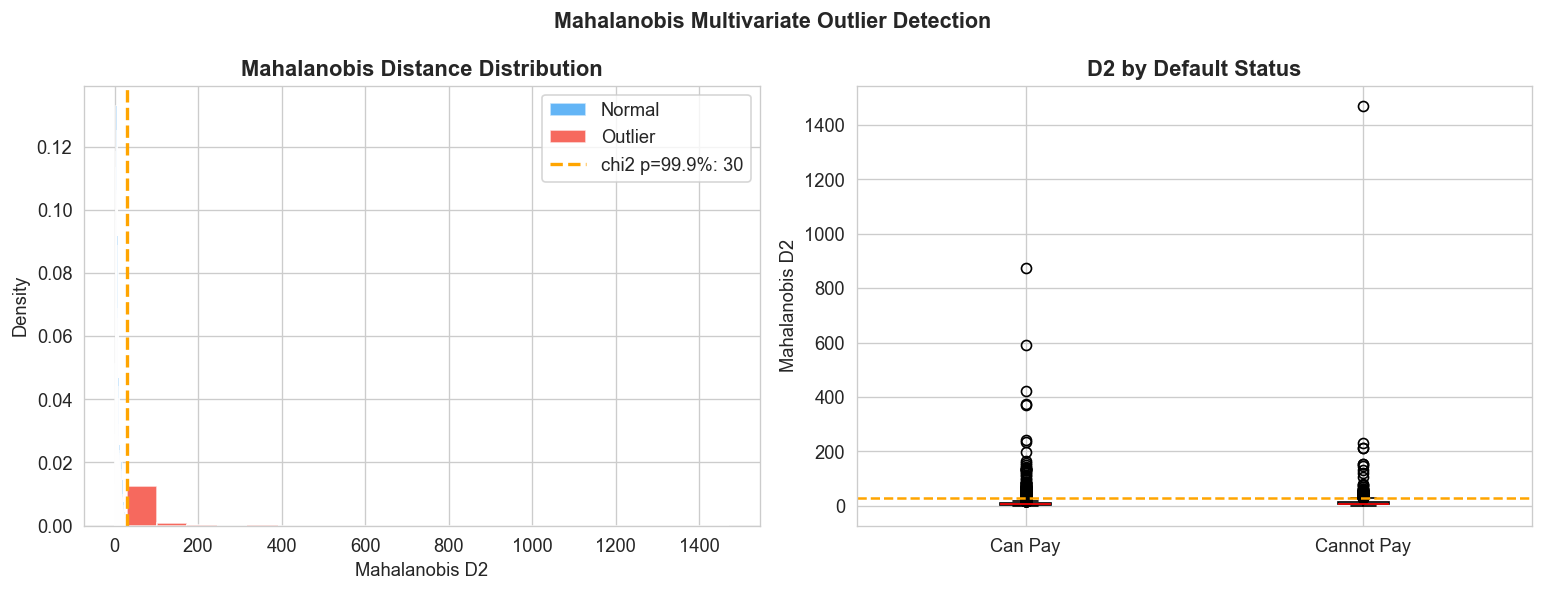

In [16]:
# Mahalanobis — vectorized (no Python row loop)
X_mah    = df[numeric_for_outliers].fillna(df[numeric_for_outliers].median()).values
cov      = np.cov(X_mah.T)
cov_inv  = np.linalg.inv(cov) if np.linalg.matrix_rank(cov) == cov.shape[0] else np.linalg.pinv(cov)
mean_vec = X_mah.mean(axis=0)
delta    = X_mah - mean_vec
mahal_sq = (delta @ cov_inv * delta).sum(axis=1)

k = X_mah.shape[1]
chi2_thr  = chi2.ppf(0.999, df=k)
df['mahal_flag'] = (mahal_sq > chi2_thr).astype(int)
n_mah = df['mahal_flag'].sum()
print(f"Mahalanobis outliers (chi2 99.9%): {n_mah} ({n_mah/len(df)*100:.1f}%) — retained")
print(f"Flagged by BOTH LOF + Mahalanobis: {((df['lof_flag']==1)&(df['mahal_flag']==1)).sum()}")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].hist(mahal_sq[df['mahal_flag']==0], bins=60, color='#2196F3', alpha=0.7, label='Normal', density=True)
axes[0].hist(mahal_sq[df['mahal_flag']==1], bins=20, color='#F44336', alpha=0.8, label='Outlier', density=True)
axes[0].axvline(chi2_thr, color='orange', linestyle='--', lw=2, label=f'chi2 p=99.9%: {chi2_thr:.0f}')
axes[0].set_xlabel('Mahalanobis D2'); axes[0].set_ylabel('Density')
axes[0].set_title('Mahalanobis Distance Distribution', fontweight='bold'); axes[0].legend()

axes[1].boxplot([mahal_sq[df['cannot_pay_back']==0], mahal_sq[df['cannot_pay_back']==1]],
                labels=['Can Pay','Cannot Pay'], patch_artist=True,
                boxprops={'facecolor':'#BBDEFB'}, medianprops={'color':'red'})
axes[1].axhline(chi2_thr, color='orange', linestyle='--')
axes[1].set_ylabel('Mahalanobis D2'); axes[1].set_title('D2 by Default Status', fontweight='bold')
plt.suptitle('Mahalanobis Multivariate Outlier Detection', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('output/10_mahalanobis.png', bbox_inches='tight')
plt.show()

### 3.4 Clustering

K-Means clustering on scaled numeric features segments the borrower population into distinct risk profiles without reference to the target variable. The optimal number of clusters is chosen by the silhouette score, which measures how well-separated the clusters are relative to their internal cohesion.

The cluster label is carried through to the model as a feature. It encodes multivariate structure — the combination of FICO, DTI, interest rate, and utilisation — that no single feature captures on its own.


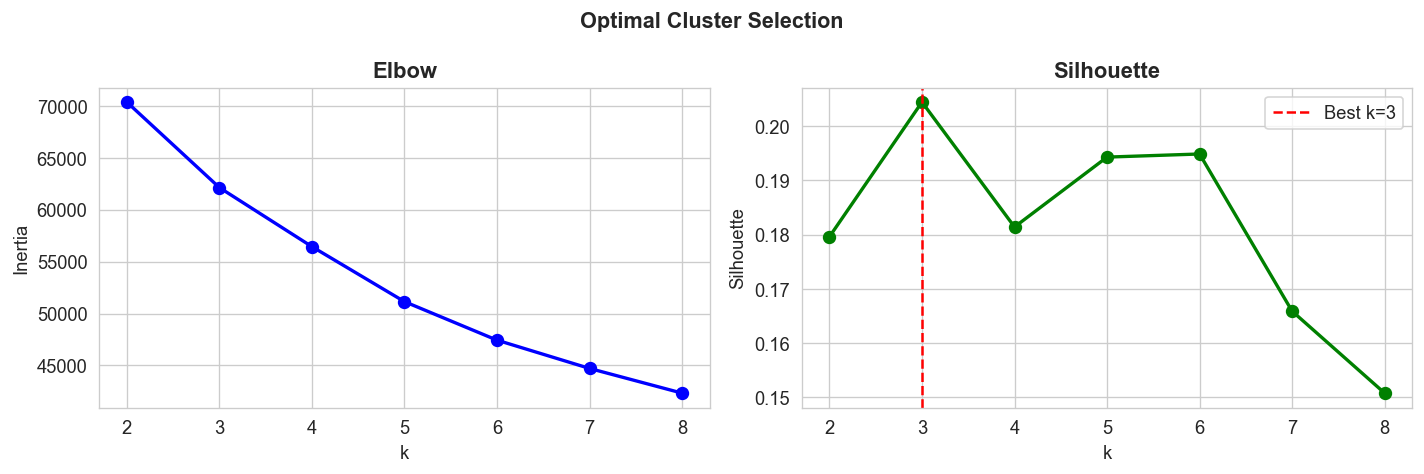

Optimal k (silhouette): 3


In [17]:
cluster_feats = ['fico','int.rate','dti','log.annual.inc','revol.util',
                  'inq.last.6mths','delinq.2yrs','pub.rec','payment_to_income_ratio']

scaler_cl = StandardScaler()
X_cl = scaler_cl.fit_transform(df[cluster_feats].fillna(df[cluster_feats].median()))

from sklearn.metrics import silhouette_score
inertias, sil_scores = [], []
K_range = range(2, 9)
for k in K_range:
    km  = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    lbl = km.fit_predict(X_cl)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_cl, lbl, sample_size=2000, random_state=RANDOM_STATE))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(K_range, inertias, 'bo-', lw=2, markersize=7)
axes[0].set_xlabel('k'); axes[0].set_ylabel('Inertia'); axes[0].set_title('Elbow', fontweight='bold')
axes[1].plot(K_range, sil_scores, 'go-', lw=2, markersize=7)
best_k = K_range[np.argmax(sil_scores)]
axes[1].axvline(best_k, color='red', linestyle='--', label=f'Best k={best_k}')
axes[1].set_xlabel('k'); axes[1].set_ylabel('Silhouette'); axes[1].set_title('Silhouette', fontweight='bold')
axes[1].legend()
plt.suptitle('Optimal Cluster Selection', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('output/11_cluster_selection.png', bbox_inches='tight')
plt.show()
print(f"Optimal k (silhouette): {best_k}")

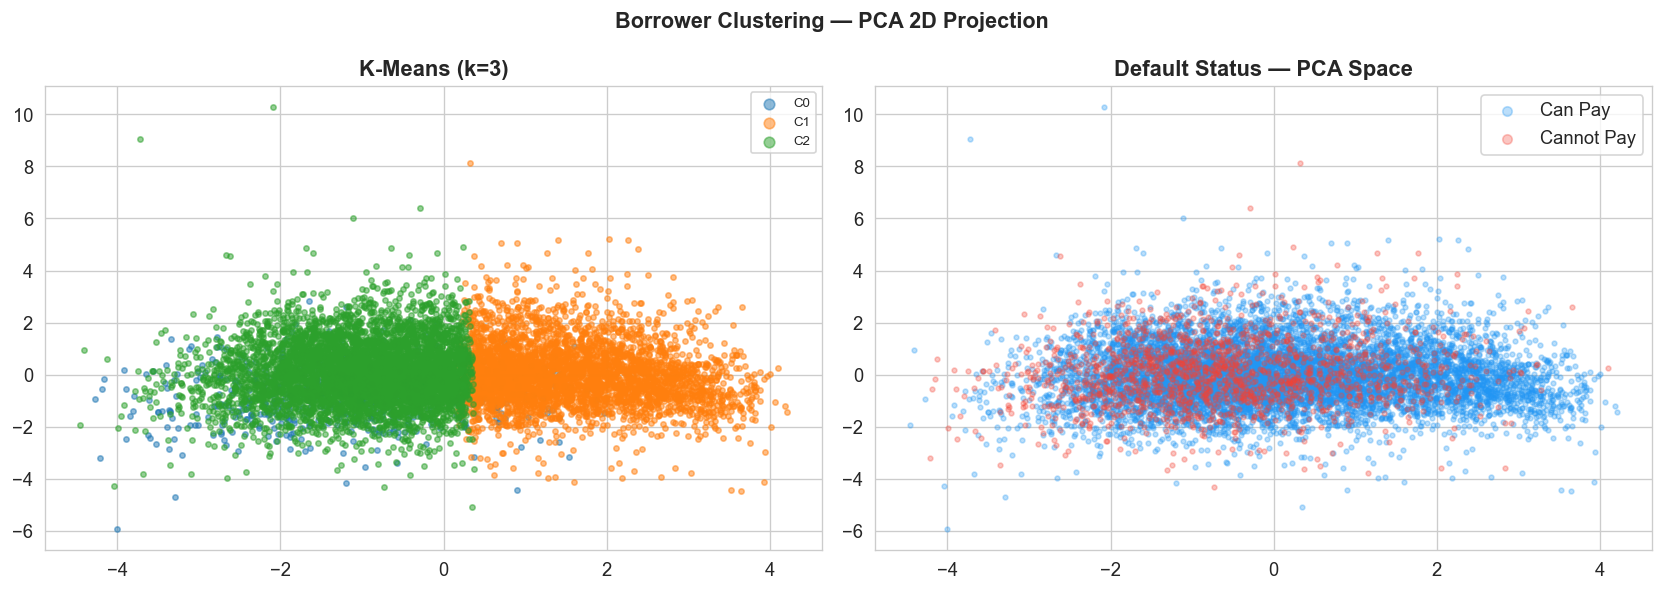

In [18]:
km_final = KMeans(n_clusters=best_k, random_state=RANDOM_STATE, n_init=15)
df['cluster'] = km_final.fit_predict(X_cl)

pca_cl = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca_cl = pca_cl.fit_transform(X_cl)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
palette_cl = sns.color_palette('tab10', best_k)
for c in range(best_k):
    m = df['cluster'] == c
    axes[0].scatter(X_pca_cl[m,0], X_pca_cl[m,1], c=[palette_cl[c]], alpha=0.5, s=10, label=f'C{c}')
axes[0].set_title(f'K-Means (k={best_k})', fontweight='bold'); axes[0].legend(markerscale=2, fontsize=8)

for t, col, lbl in [(0,'#2196F3','Can Pay'), (1,'#F44336','Cannot Pay')]:
    m = df['cannot_pay_back'] == t
    axes[1].scatter(X_pca_cl[m,0], X_pca_cl[m,1], c=col, alpha=0.3, s=8, label=lbl)
axes[1].set_title('Default Status — PCA Space', fontweight='bold'); axes[1].legend(markerscale=2)
plt.suptitle('Borrower Clustering — PCA 2D Projection', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('output/12_cluster_pca.png', bbox_inches='tight')
plt.show()

Cluster Risk Profiles (cluster label used as feature in Section 4):
            n  default_rate  avg_fico  avg_int_rate  avg_dti  avg_dscr  risk
cluster                                                                     
0         559         0.247   688.440         0.133   12.912    27.787  HIGH
1        3767         0.102   745.906         0.100    9.621    28.821   LOW
2        5252         0.192   688.084         0.138   14.715    22.934   MED


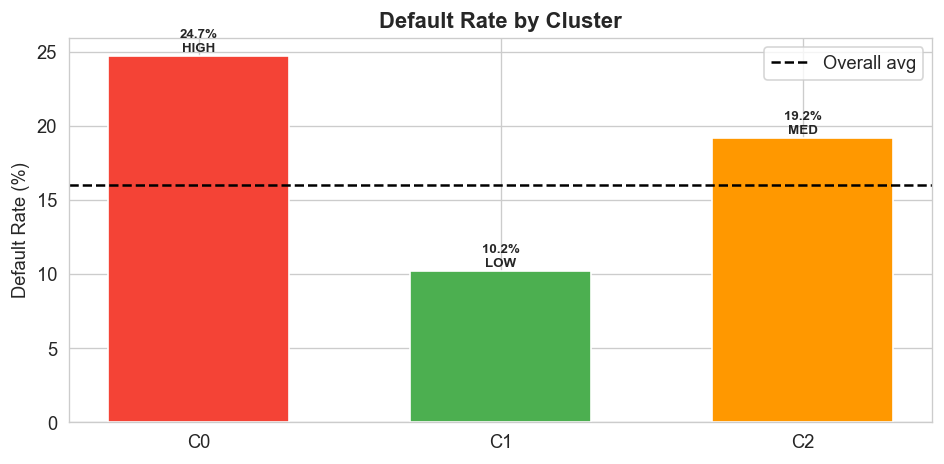

In [19]:
cluster_profile = df.groupby('cluster').agg(
    n=('cannot_pay_back','count'),
    default_rate=('cannot_pay_back','mean'),
    avg_fico=('fico','mean'),
    avg_int_rate=('int.rate','mean'),
    avg_dti=('dti','mean'),
    avg_dscr=('dscr_proxy','mean'),
).round(3)
cluster_profile['risk'] = cluster_profile['default_rate'].apply(
    lambda r: 'HIGH' if r > 0.22 else ('MED' if r > 0.13 else 'LOW'))
print("Cluster Risk Profiles (cluster label used as feature in Section 4):")
print(cluster_profile.to_string())

fig, ax = plt.subplots(figsize=(8, 4))
dr_vals = cluster_profile['default_rate'].values * 100
bar_cols = ['#F44336' if r>22 else ('#FF9800' if r>13 else '#4CAF50') for r in dr_vals]
bars = ax.bar(range(best_k), dr_vals, color=bar_cols, edgecolor='white', width=0.6)
ax.axhline(df['cannot_pay_back'].mean()*100, color='black', linestyle='--', lw=1.5, label='Overall avg')
for i, (b, lbl) in enumerate(zip(bars, cluster_profile['risk'])):
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.3,
            f'{dr_vals[i]:.1f}%\n{lbl}', ha='center', fontsize=8, fontweight='bold')
ax.set_xticks(range(best_k)); ax.set_xticklabels([f'C{i}' for i in range(best_k)])
ax.set_ylabel('Default Rate (%)'); ax.set_title('Default Rate by Cluster', fontweight='bold')
ax.legend(); plt.tight_layout()
plt.savefig('output/13_cluster_profiles.png', bbox_inches='tight')
plt.show()

## 4. Preprocessing

The EDA findings drive five decisions applied here in sequence. `purpose` is one-hot encoded with one category dropped to avoid multicollinearity. `log.annual.inc`, `lof_flag`, and `mahal_flag` are dropped: log income is fully captured by the derived capacity features, and the outlier flags add no signal the models cannot derive from FICO and DTI directly.

Four right-skewed columns are IQR-capped at 1.5× the interquartile range: `installment`, `days.with.cr.line`, `revol.bal`, `inq.last.6mths`, and `monthly_income`. Capping is applied after the train/test split to prevent test data influencing the cap boundaries.

The split is stratified 80/20, preserving the 16% default rate in both partitions. The scaler is fit on training data only and applied to both sets — standard discipline to prevent target leakage.


In [20]:
df_model = df.copy()

purpose_dummies = pd.get_dummies(df_model['purpose'], prefix='purpose', drop_first=True)
df_model = pd.concat([df_model.drop(columns=['purpose']), purpose_dummies], axis=1)

drop_cols = ['occ_tier', 'log.annual.inc', 'lof_flag', 'mahal_flag']
df_model.drop(columns=[c for c in drop_cols if c in df_model.columns], inplace=True)

iqr_cap_cols = ['installment','days.with.cr.line','revol.bal','inq.last.6mths','monthly_income']
for col in iqr_cap_cols:
    q1, q3 = df_model[col].quantile([0.25, 0.75])
    df_model[col] = df_model[col].clip(q1 - 1.5*(q3-q1), q3 + 1.5*(q3-q1))

TARGET = 'cannot_pay_back'
feature_cols = [c for c in df_model.columns if c != TARGET]
X = df_model[feature_cols].values
y = df_model[TARGET].values

print(f"Feature matrix: {X.shape}")
print(f"Features ({len(feature_cols)}): {feature_cols}")
print(f"Class distribution: {dict(zip(*np.unique(y, return_counts=True)))}")

Feature matrix: (9578, 28)
Features (28): ['credit.policy', 'int.rate', 'installment', 'dti', 'fico', 'days.with.cr.line', 'revol.bal', 'revol.util', 'inq.last.6mths', 'delinq.2yrs', 'pub.rec', 'monthly_income', 'payment_to_income_ratio', 'dscr_proxy', 'debt_burden_annual', 'dti_flag', 'high_utilization_flag', 'delinquency_flag', 'public_record_flag', 'credit_years', 'occ_tier_code', 'cluster', 'purpose_credit_card', 'purpose_debt_consolidation', 'purpose_educational', 'purpose_home_improvement', 'purpose_major_purchase', 'purpose_small_business']
Class distribution: {np.int64(0): np.int64(8045), np.int64(1): np.int64(1533)}


In [21]:
# Stratified 80/20 split; original indices preserved for OCC cohort evaluation
all_idx = np.arange(len(X))
X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
    X, y, all_idx, test_size=0.2, stratify=y, random_state=RANDOM_STATE)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f"Train: {X_train_sc.shape} | positives: {y_train.sum()} ({y_train.mean()*100:.1f}%)")
print(f"Test:  {X_test_sc.shape}  | positives: {y_test.sum()} ({y_test.mean()*100:.1f}%)")
print("Test set preserves original 16% default rate — never resampled")

Train: (7662, 28) | positives: 1226 (16.0%)
Test:  (1916, 28)  | positives: 307 (16.0%)
Test set preserves original 16% default rate — never resampled


## 5. Class Imbalance: SMOTE-ENN

Logistic Regression uses SMOTE-ENN resampling on the training set to supplement its `class_weight='balanced'` penalty. SMOTE generates synthetic minority-class examples by interpolating between real defaulters in feature space. ENN then removes borderline examples from both classes that the nearest neighbours would misclassify, cleaning the boundary between classes.

The tree-based models — Random Forest, XGBoost, and LightGBM — do not use SMOTE-ENN. They handle class imbalance through their native mechanisms: `class_weight='balanced_subsample'` for Random Forest, `scale_pos_weight` for XGBoost, and `is_unbalance=True` for LightGBM. Applying SMOTE-ENN on top of these mechanisms caused the tree models to learn the synthetic sample distribution rather than the real one, producing ROC-AUC gaps of 0.28–0.30 between training and test — a clear sign of overfitting to synthetic data.

The test set is never resampled. It preserves the original 16% default rate throughout.


Before SMOTE-ENN: 7,662 | 0:6,436 | 1:1,226
After  SMOTE-ENN: 9,166 | 0:3,253 | 1:5,913


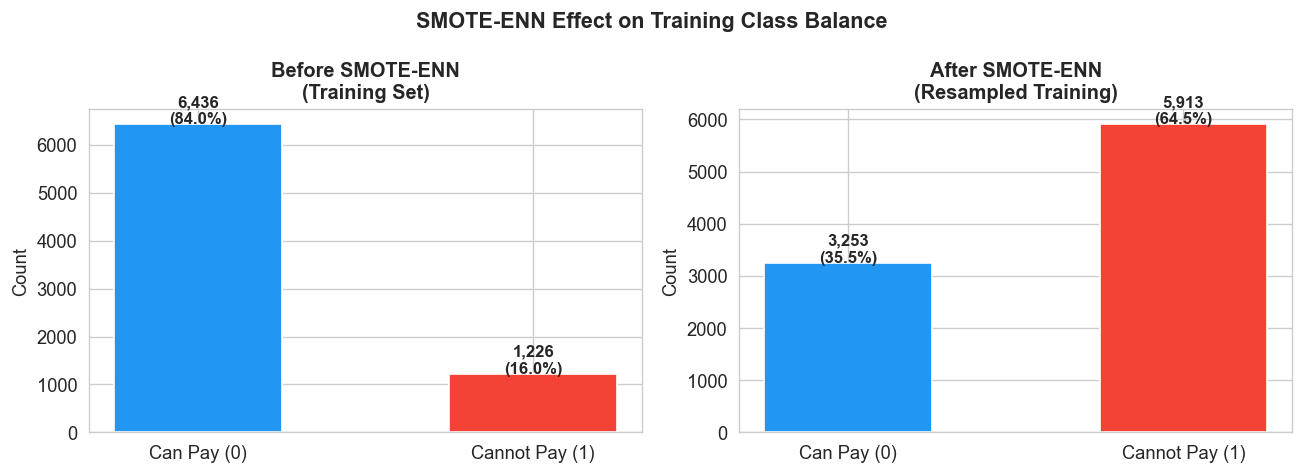

In [22]:
smoteenn = SMOTEENN(random_state=RANDOM_STATE)
X_train_res, y_train_res = smoteenn.fit_resample(X_train_sc, y_train)

print(f"Before SMOTE-ENN: {len(y_train):,} | 0:{(y_train==0).sum():,} | 1:{(y_train==1).sum():,}")
print(f"After  SMOTE-ENN: {len(y_train_res):,} | 0:{(y_train_res==0).sum():,} | 1:{(y_train_res==1).sum():,}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, (y_data, title) in zip(axes, [
        (y_train,     'Before SMOTE-ENN\n(Training Set)'),
        (y_train_res, 'After SMOTE-ENN\n(Resampled Training)')]):
    counts = np.bincount(y_data)
    bars = ax.bar(['Can Pay (0)','Cannot Pay (1)'], counts,
                  color=['#2196F3','#F44336'], width=0.5, edgecolor='white')
    for b, c in zip(bars, counts):
        ax.text(b.get_x()+b.get_width()/2, b.get_height()+5,
                f'{c:,}\n({c/len(y_data)*100:.1f}%)', ha='center', fontsize=10, fontweight='bold')
    ax.set_title(title, fontsize=12, fontweight='bold'); ax.set_ylabel('Count')

plt.suptitle('SMOTE-ENN Effect on Training Class Balance', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('output/14_smoteenn.png', bbox_inches='tight')
plt.show()

## 6. Model Training & Comparison

Four models are trained and compared. Each is tuned with an Optuna study of 50 trials using 5-fold stratified cross-validation, with recall on the default class as the objective. Hyperparameter search is conducted on the training data using the same class-imbalance strategy that will be used for the final model — no leakage from the test set.

The evaluation suite for each model includes a confusion matrix, classification report, ROC curve, Precision-Recall curve, and Precision-Recall Gain (PRG) curve. The PRG curve penalises performance near the random baseline more heavily than the standard PR curve, making it the most informative metric for severely imbalanced problems.

| Model | Imbalance Strategy | Tuning Data |
|---|---|---|
| Logistic Regression | `class_weight='balanced'` + SMOTE-ENN | Resampled train |
| Random Forest | `class_weight='balanced_subsample'` | Original train |
| XGBoost | `scale_pos_weight = neg/pos` | Original train |
| LightGBM | `is_unbalance=True` | Original train |


In [23]:
def evaluate_model(model, X_te, y_te, model_name, results_store):
    y_pred = model.predict(X_te)
    y_prob = model.predict_proba(X_te)[:, 1]
    rec1   = recall_score(y_te, y_pred, pos_label=1)
    prec1  = precision_score(y_te, y_pred, pos_label=1, zero_division=0)
    f1_1   = f1_score(y_te, y_pred, pos_label=1)
    roc    = roc_auc_score(y_te, y_prob)
    fn     = int(((y_te==1) & (y_pred==0)).sum())
    pg, rg, auprg = compute_prg_curve(y_te, y_prob)
    results_store[model_name] = {
        'recall_1':rec1, 'precision_1':prec1, 'f1_1':f1_1, 'roc_auc':roc,
        'auprg':auprg, 'fn_count':fn, 'y_pred':y_pred, 'y_prob':y_prob, 'pg':pg, 'rg':rg
    }
    print(f"\n{'='*55}\n {model_name}\n{'='*55}")
    print(f"  Recall   (class 1): {rec1:.4f}  <- PRIMARY METRIC")
    print(f"  Precision(class 1): {prec1:.4f}")
    print(f"  F1       (class 1): {f1_1:.4f}")
    print(f"  ROC-AUC:            {roc:.4f}")
    print(f"  AUPRG:              {auprg:.4f}")
    print(f"  False Negatives:    {fn} (missed defaulters)")
    print(classification_report(y_te, y_pred, target_names=['Can Pay','Cannot Pay']))


def plot_model_results(model, X_te, y_te, model_name, results_store, prefix):
    r = results_store[model_name]
    y_pred, y_prob, pg, rg = r['y_pred'], r['y_prob'], r['pg'], r['rg']
    fig, axes = plt.subplots(2, 2, figsize=(13, 10))

    cm = confusion_matrix(y_te, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=['Can Pay','Cannot Pay']).plot(
        ax=axes[0,0], colorbar=False, cmap='Blues')
    axes[0,0].set_title(f'Confusion Matrix — FN={cm[1,0]}', fontweight='bold')

    fpr, tpr, _ = roc_curve(y_te, y_prob)
    axes[0,1].plot(fpr, tpr, '#1565C0', lw=2, label=f'AUC={r["roc_auc"]:.3f}')
    axes[0,1].plot([0,1],[0,1],'k--',lw=1,alpha=0.5)
    axes[0,1].set_xlabel('FPR'); axes[0,1].set_ylabel('TPR')
    axes[0,1].set_title('ROC Curve', fontweight='bold'); axes[0,1].legend()

    prec_arr, rec_arr, _ = precision_recall_curve(y_te, y_prob)
    axes[1,0].plot(rec_arr, prec_arr, '#C62828', lw=2,
                   label=f'AP={average_precision_score(y_te, y_prob):.3f}')
    axes[1,0].axhline(y_te.mean(), color='gray', linestyle='--', lw=1, label='Random baseline')
    axes[1,0].set_xlabel('Recall'); axes[1,0].set_ylabel('Precision')
    axes[1,0].set_title('Precision-Recall Curve', fontweight='bold'); axes[1,0].legend()

    axes[1,1].plot(rg, pg, '#2E7D32', lw=2.5, label=f'AUPRG={r["auprg"]:.3f}')
    axes[1,1].fill_between(rg, pg, 0, where=(rg>=0), alpha=0.15, color='#2E7D32')
    axes[1,1].axhline(0,color='gray',linestyle='--',lw=1,alpha=0.5)
    axes[1,1].axvline(0,color='gray',linestyle='--',lw=1,alpha=0.5)
    axes[1,1].set_xlabel('Recall Gain'); axes[1,1].set_ylabel('Precision Gain')
    axes[1,1].set_title('PRG Curve (0=random, 1=perfect)', fontweight='bold')
    axes[1,1].set_xlim(-0.05,1.05); axes[1,1].set_ylim(-0.05,1.05); axes[1,1].legend()

    plt.suptitle(f'{model_name} — Evaluation Dashboard', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'output/{prefix}_eval.png', bbox_inches='tight')
    plt.show()


MODEL_RESULTS = {}
print("Evaluation helpers defined.")

Evaluation helpers defined.


### 6.1 Logistic Regression

Logistic Regression is the baseline and the interpretability anchor. Its coefficients are directly readable as log-odds: a one-unit increase in FICO score lowers the log-odds of default by a fixed amount, and that relationship is constant across the feature space. This makes it auditable under CFPB adverse action notice requirements — the lender can explain any rejection in plain terms derived from the model's weights.

Optuna searches over regularisation strength `C` and solver. The SMOTE-ENN resampled training set is used for cross-validation.


In [24]:
def lr_objective(trial):
    C      = trial.suggest_float('C', 1e-3, 10.0, log=True)
    solver = trial.suggest_categorical('solver', ['lbfgs','liblinear'])
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    model = LogisticRegression(C=C, penalty='l2', solver=solver,
                               class_weight='balanced', max_iter=1000, random_state=RANDOM_STATE)
    return cross_val_score(model, X_train_res, y_train_res, cv=cv, scoring='recall', n_jobs=-1).mean()

study_lr = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study_lr.optimize(lr_objective, n_trials=50, show_progress_bar=True)
best_lr_params = study_lr.best_params
print(f"Best LR params: {best_lr_params}")
print(f"Best CV recall: {study_lr.best_value:.4f}")

Best trial: 41. Best value: 0.698797: 100%|██████████| 50/50 [00:13<00:00,  3.81it/s]

Best LR params: {'C': 0.001022387163625499, 'solver': 'liblinear'}
Best CV recall: 0.6988



 Logistic Regression
  Recall   (class 1): 0.6482  <- PRIMARY METRIC
  Precision(class 1): 0.2267
  F1       (class 1): 0.3359
  ROC-AUC:            0.6758
  AUPRG:              0.5677
  False Negatives:    108 (missed defaulters)
              precision    recall  f1-score   support

     Can Pay       0.90      0.58      0.70      1609
  Cannot Pay       0.23      0.65      0.34       307

    accuracy                           0.59      1916
   macro avg       0.56      0.61      0.52      1916
weighted avg       0.79      0.59      0.64      1916



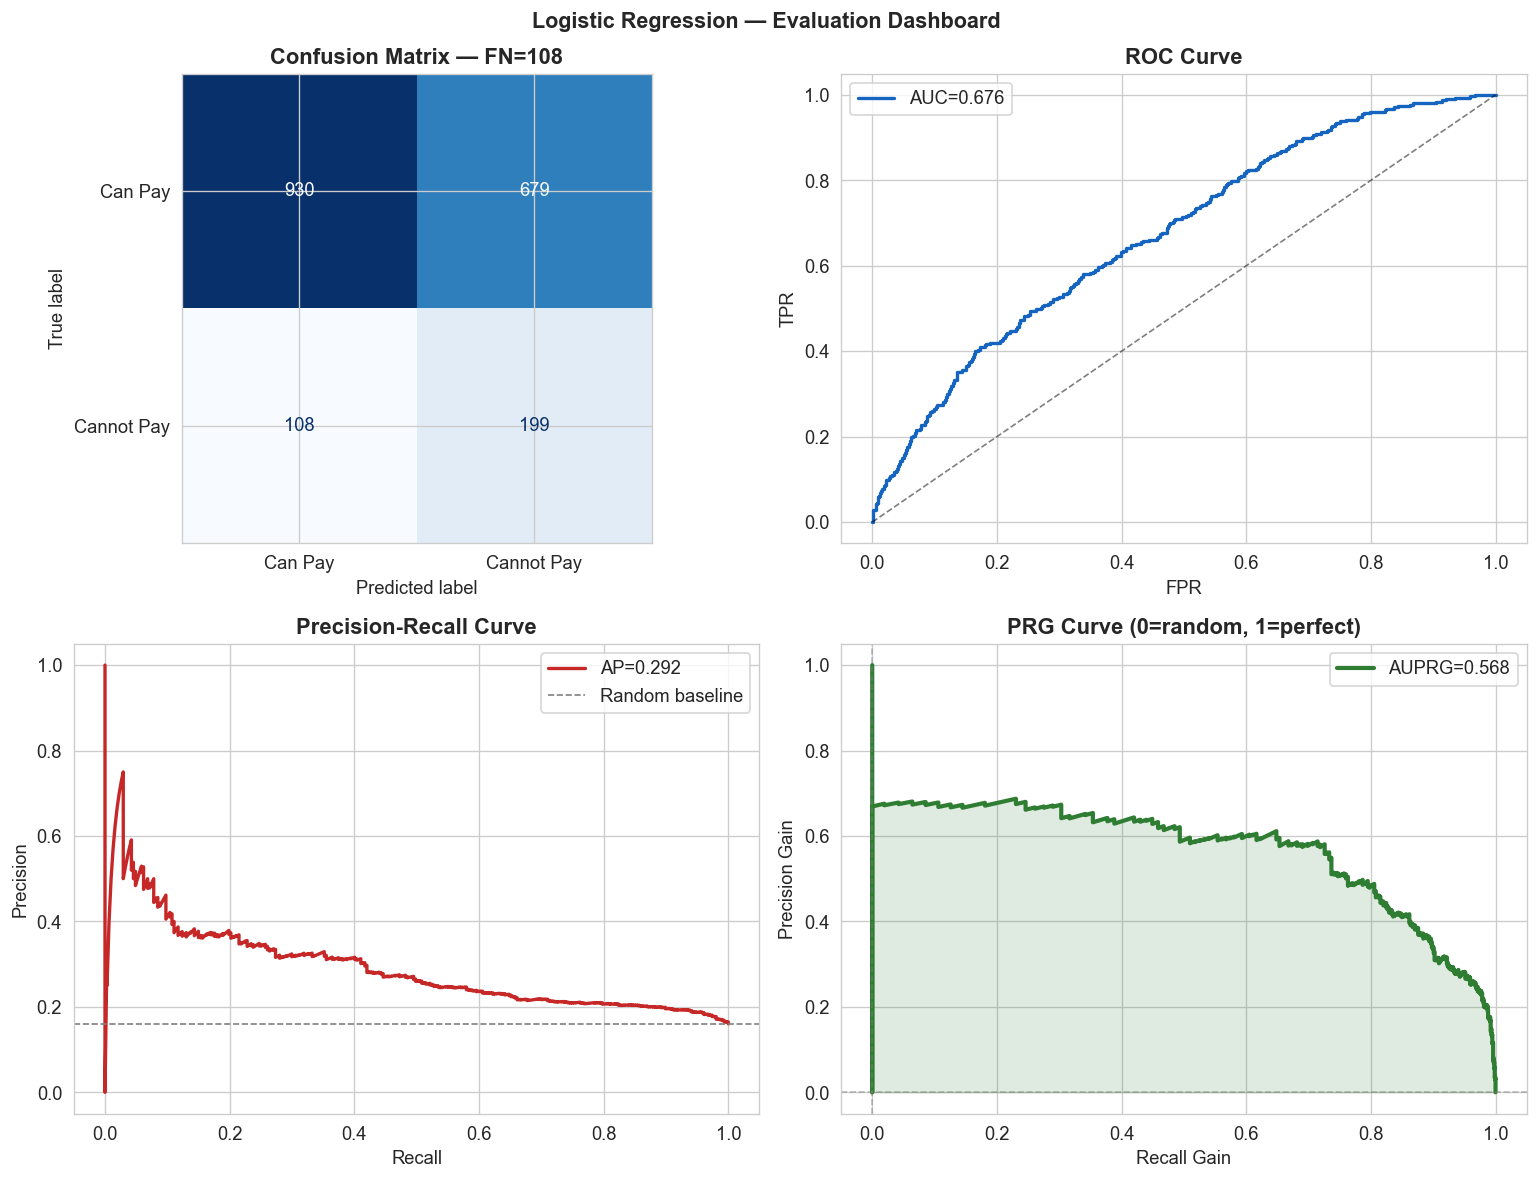

In [25]:
lr_model = LogisticRegression(**best_lr_params, class_weight='balanced',
                              max_iter=1000, random_state=RANDOM_STATE)
lr_model.fit(X_train_res, y_train_res)
evaluate_model(lr_model, X_test_sc, y_test, 'Logistic Regression', MODEL_RESULTS)
plot_model_results(lr_model, X_test_sc, y_test, 'Logistic Regression', MODEL_RESULTS, '15_lr')

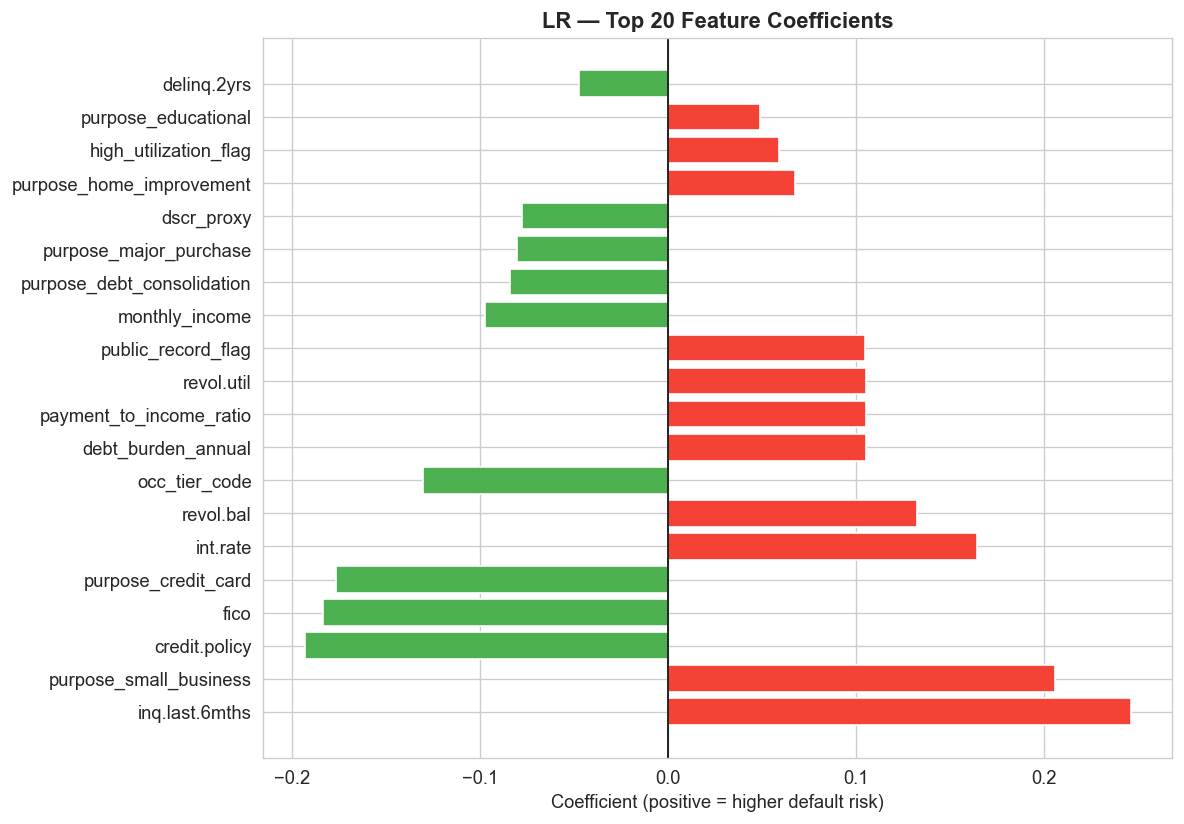

In [26]:
coef_df = pd.DataFrame({'Feature':feature_cols, 'Coefficient':lr_model.coef_[0]})
coef_df = coef_df.reindex(coef_df['Coefficient'].abs().sort_values(ascending=False).index)
fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(coef_df['Feature'].head(20), coef_df['Coefficient'].head(20),
        color=['#F44336' if c>0 else '#4CAF50' for c in coef_df['Coefficient'].head(20)])
ax.axvline(0, color='black', lw=1)
ax.set_xlabel('Coefficient (positive = higher default risk)')
ax.set_title('LR — Top 20 Feature Coefficients', fontweight='bold')
plt.tight_layout()
plt.savefig('output/16_lr_coefficients.png', bbox_inches='tight')
plt.show()

### 6.2 Random Forest

Random Forest builds an ensemble of decision trees, each trained on a bootstrapped subsample of the data and a random subset of features. Averaging across trees reduces the variance that any single deep tree would exhibit. `class_weight='balanced_subsample'` adjusts the class weights independently for each bootstrap sample, matching the resampling approach to the ensemble mechanism.

Optuna searches over tree count, depth, split and leaf size thresholds, and feature sampling strategy. Cross-validation runs on the original imbalanced training data.


In [27]:
def rf_objective(trial):
    params = dict(
        n_estimators     = trial.suggest_int('n_estimators', 100, 500, step=50),
        max_depth        = trial.suggest_int('max_depth', 3, 15),
        min_samples_split= trial.suggest_int('min_samples_split', 2, 30),
        min_samples_leaf = trial.suggest_int('min_samples_leaf', 1, 20),
        max_features     = trial.suggest_categorical('max_features', ['sqrt','log2']),
    )
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    model = RandomForestClassifier(**params, class_weight='balanced_subsample',
                                   random_state=RANDOM_STATE, n_jobs=-1)
    return cross_val_score(model, X_train_sc, y_train, cv=cv, scoring='recall', n_jobs=-1).mean()

study_rf = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study_rf.optimize(rf_objective, n_trials=50, show_progress_bar=True)
best_rf_params = study_rf.best_params
print(f"Best RF params: {best_rf_params}")
print(f"Best CV recall: {study_rf.best_value:.4f}")


Best trial: 46. Best value: 0.645996: 100%|██████████| 50/50 [01:36<00:00,  1.93s/it]

Best RF params: {'n_estimators': 500, 'max_depth': 3, 'min_samples_split': 10, 'min_samples_leaf': 3, 'max_features': 'log2'}
Best CV recall: 0.6460



 Random Forest
  Recall   (class 1): 0.6026  <- PRIMARY METRIC
  Precision(class 1): 0.2218
  F1       (class 1): 0.3243
  ROC-AUC:            0.6580
  AUPRG:              0.5177
  False Negatives:    122 (missed defaulters)
              precision    recall  f1-score   support

     Can Pay       0.89      0.60      0.71      1609
  Cannot Pay       0.22      0.60      0.32       307

    accuracy                           0.60      1916
   macro avg       0.55      0.60      0.52      1916
weighted avg       0.78      0.60      0.65      1916



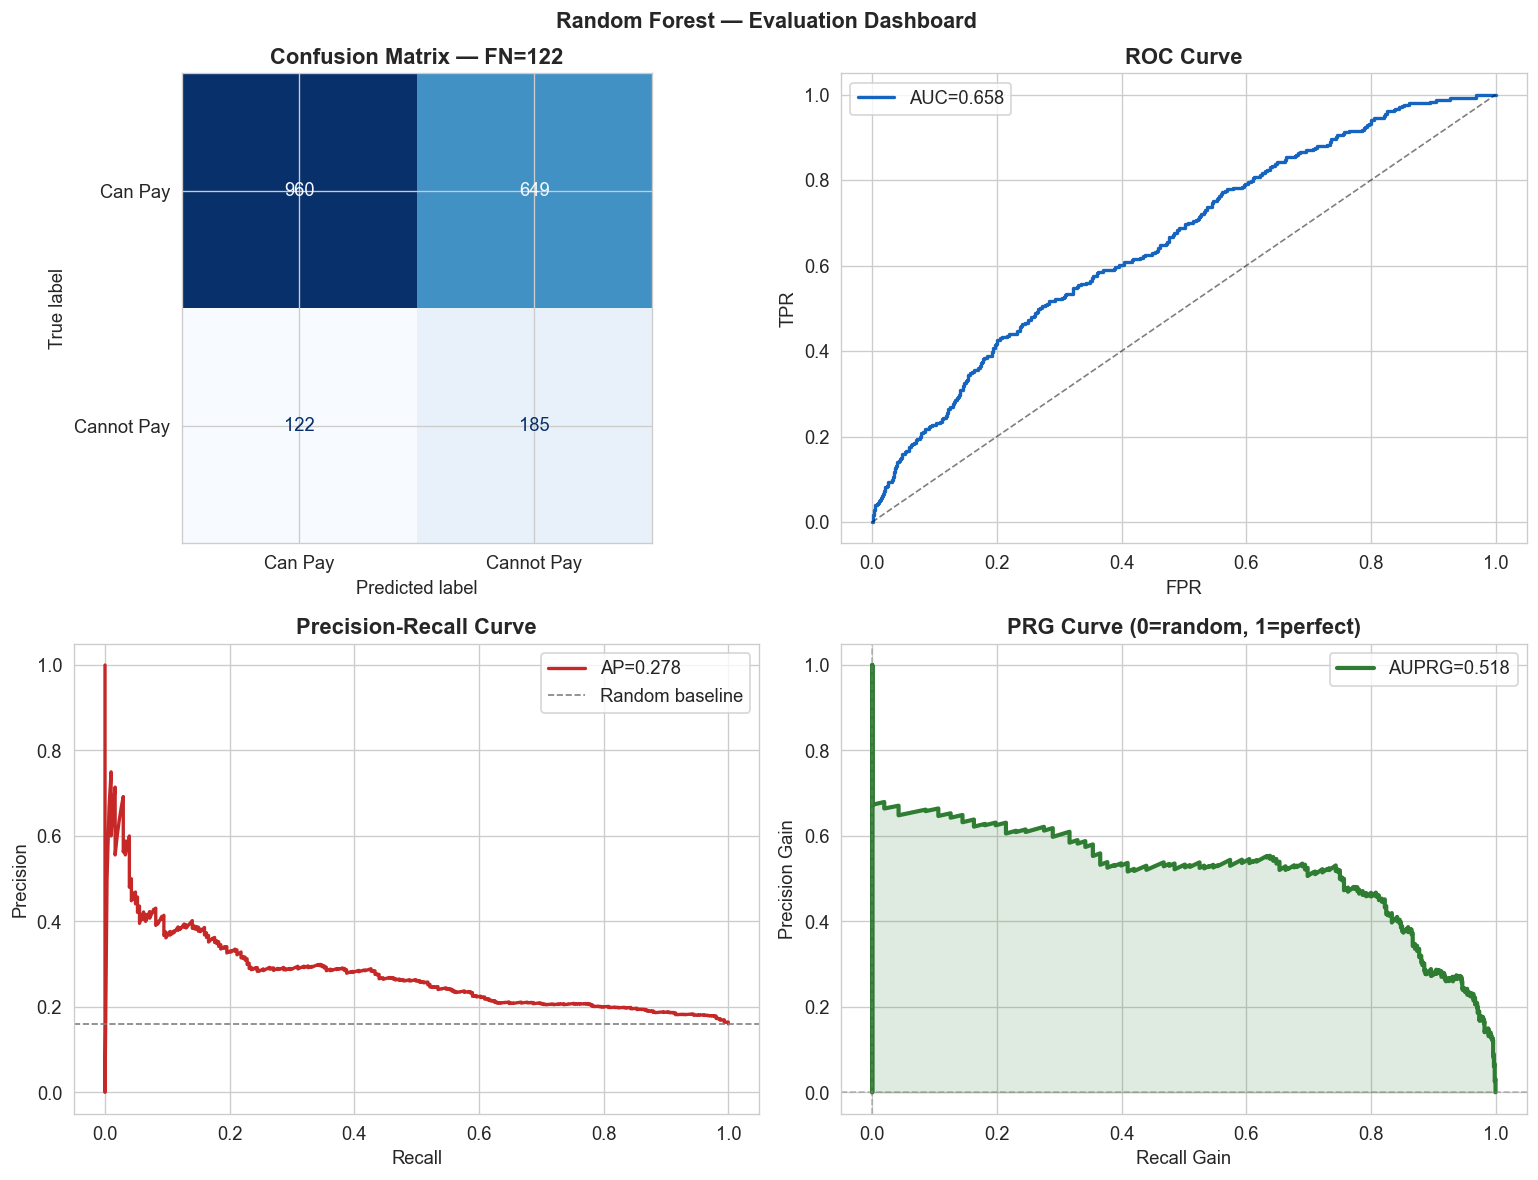

In [28]:
rf_model = RandomForestClassifier(**best_rf_params, class_weight='balanced_subsample',
                                   random_state=RANDOM_STATE, n_jobs=-1)
rf_model.fit(X_train_sc, y_train)
evaluate_model(rf_model, X_test_sc, y_test, 'Random Forest', MODEL_RESULTS)
plot_model_results(rf_model, X_test_sc, y_test, 'Random Forest', MODEL_RESULTS, '17_rf')


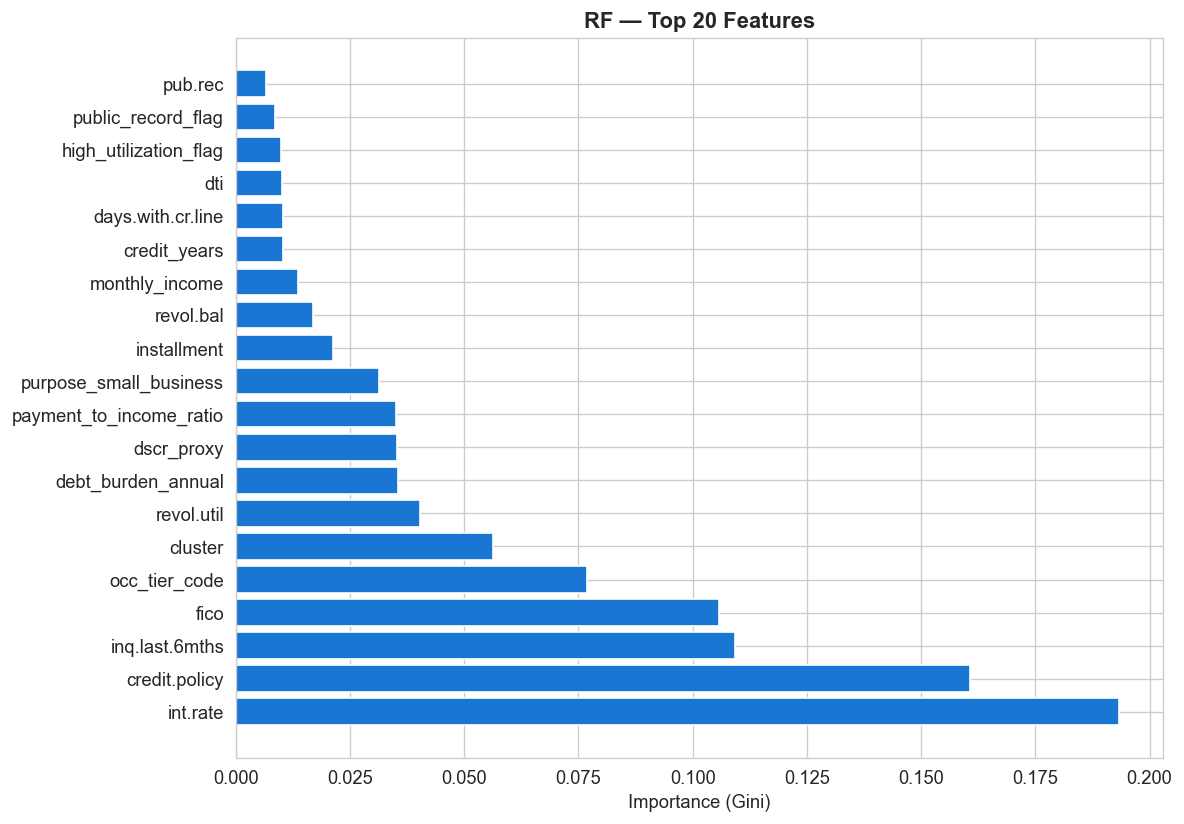

In [29]:
fi_df = pd.DataFrame({'Feature':feature_cols,'Importance':rf_model.feature_importances_})
fi_df = fi_df.sort_values('Importance', ascending=False).head(20)
fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(fi_df['Feature'], fi_df['Importance'], color='#1976D2')
ax.set_xlabel('Importance (Gini)'); ax.set_title('RF — Top 20 Features', fontweight='bold')
plt.tight_layout(); plt.savefig('output/18_rf_importance.png', bbox_inches='tight'); plt.show()

### 6.3 XGBoost

XGBoost builds trees sequentially, with each tree correcting the residual errors of its predecessors. `scale_pos_weight` tells the algorithm to treat each defaulter as equivalent to `neg/pos ≈ 5.25` non-defaulters when computing gradients, directly weighting the minority class in the loss function.

Optuna searches over tree count, depth, learning rate, subsampling rates, regularisation penalties, and the minimum child weight that controls leaf-level complexity. Cross-validation runs on the original imbalanced training data.


In [30]:
# scale_pos_weight from original class distribution
scale_pos_weight_val = float((y_train == 0).sum() / (y_train == 1).sum())
print(f"scale_pos_weight = {scale_pos_weight_val:.4f}")

def xgb_objective(trial):
    params = dict(
        n_estimators    = trial.suggest_int('n_estimators', 100, 500, step=50),
        max_depth       = trial.suggest_int('max_depth', 3, 8),
        learning_rate   = trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        subsample       = trial.suggest_float('subsample', 0.5, 1.0),
        colsample_bytree= trial.suggest_float('colsample_bytree', 0.5, 1.0),
        min_child_weight= trial.suggest_int('min_child_weight', 1, 20),
        gamma           = trial.suggest_float('gamma', 0, 2.0),
        reg_alpha       = trial.suggest_float('reg_alpha', 0, 2.0),
        reg_lambda      = trial.suggest_float('reg_lambda', 0.5, 5.0),
    )
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    model = XGBClassifier(**params, scale_pos_weight=scale_pos_weight_val,
                          eval_metric='logloss', random_state=RANDOM_STATE, verbosity=0, n_jobs=-1)
    return cross_val_score(model, X_train_sc, y_train, cv=cv, scoring='recall', n_jobs=-1).mean()

study_xgb = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study_xgb.optimize(xgb_objective, n_trials=50, show_progress_bar=True)
best_xgb_params = study_xgb.best_params
print(f"Best XGB params: {best_xgb_params}")
print(f"Best CV recall: {study_xgb.best_value:.4f}")


scale_pos_weight = 5.2496


Best trial: 45. Best value: 0.591366: 100%|██████████| 50/50 [00:17<00:00,  2.88it/s]

Best XGB params: {'n_estimators': 300, 'max_depth': 3, 'learning_rate': 0.011781405032310831, 'subsample': 0.5857626136164138, 'colsample_bytree': 0.5408596816306049, 'min_child_weight': 16, 'gamma': 0.6202290122663126, 'reg_alpha': 0.9591964505818975, 'reg_lambda': 4.491154702421807}
Best CV recall: 0.5914



 XGBoost
  Recall   (class 1): 0.5537  <- PRIMARY METRIC
  Precision(class 1): 0.2418
  F1       (class 1): 0.3366
  ROC-AUC:            0.6661
  AUPRG:              0.5193
  False Negatives:    137 (missed defaulters)
              precision    recall  f1-score   support

     Can Pay       0.89      0.67      0.76      1609
  Cannot Pay       0.24      0.55      0.34       307

    accuracy                           0.65      1916
   macro avg       0.56      0.61      0.55      1916
weighted avg       0.78      0.65      0.69      1916



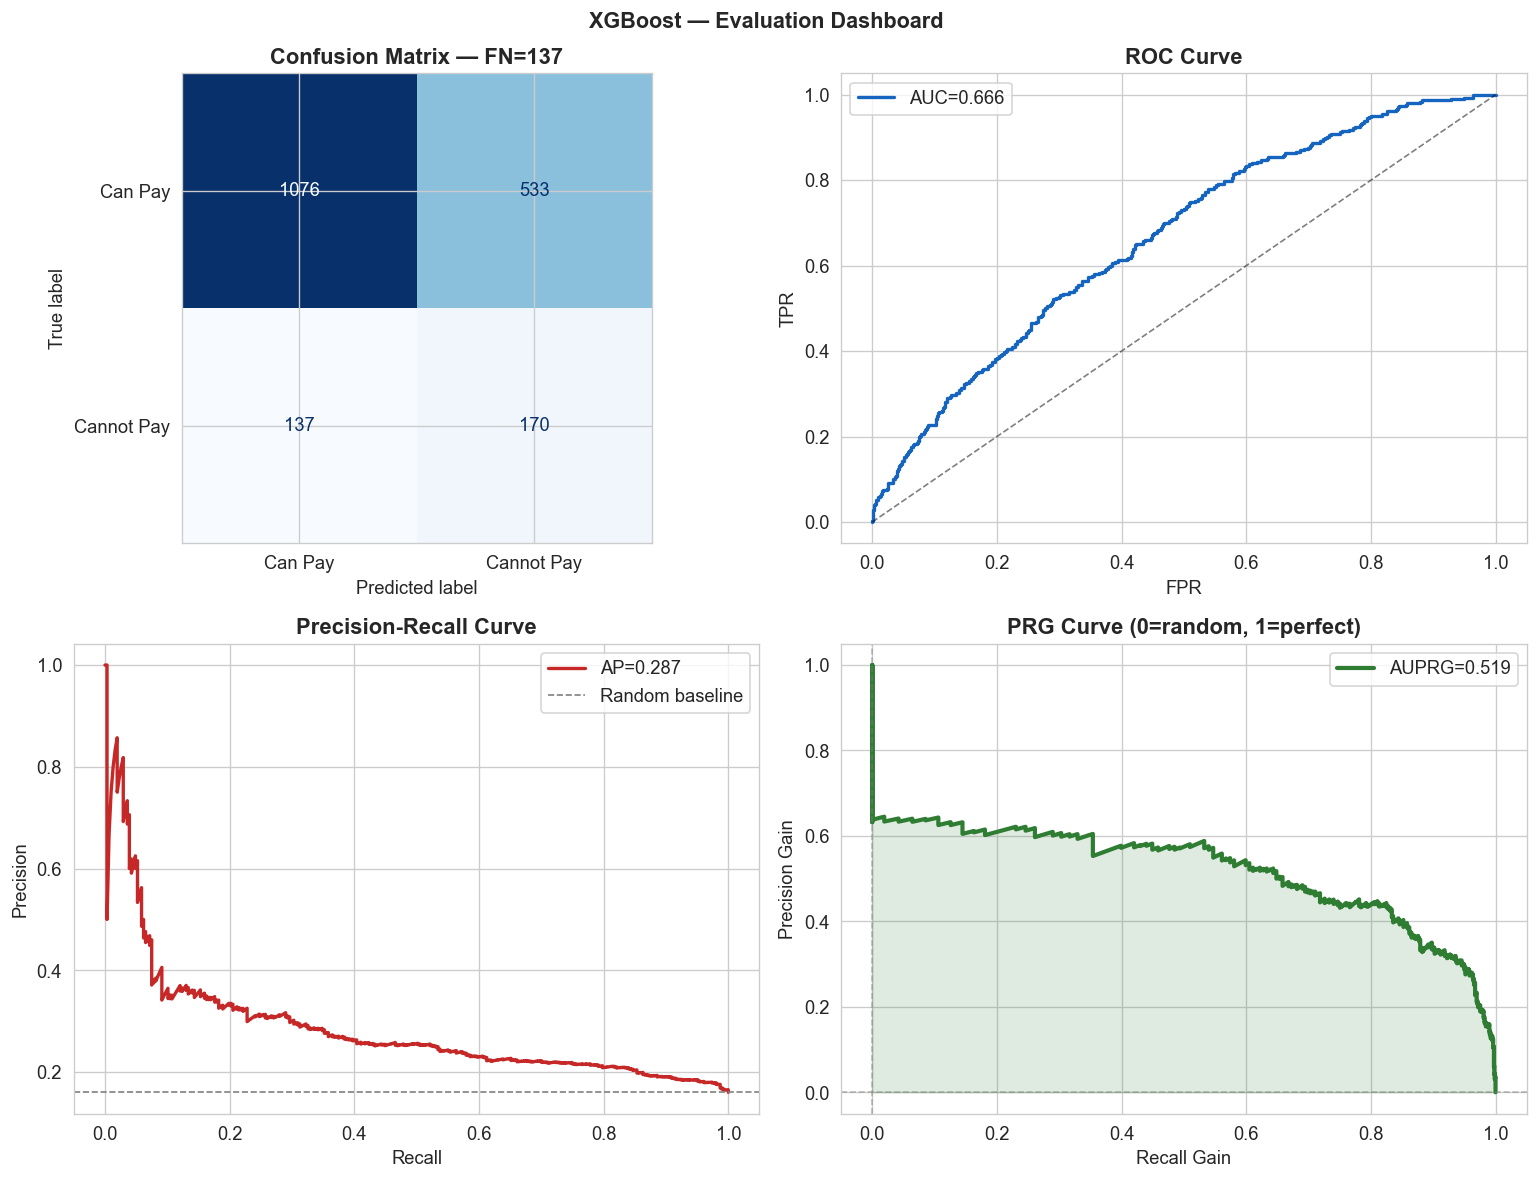

In [31]:
xgb_model = XGBClassifier(**best_xgb_params, scale_pos_weight=scale_pos_weight_val,
                          eval_metric='logloss', random_state=RANDOM_STATE, verbosity=0, n_jobs=-1)
xgb_model.fit(X_train_sc, y_train)
evaluate_model(xgb_model, X_test_sc, y_test, 'XGBoost', MODEL_RESULTS)
plot_model_results(xgb_model, X_test_sc, y_test, 'XGBoost', MODEL_RESULTS, '19_xgb')


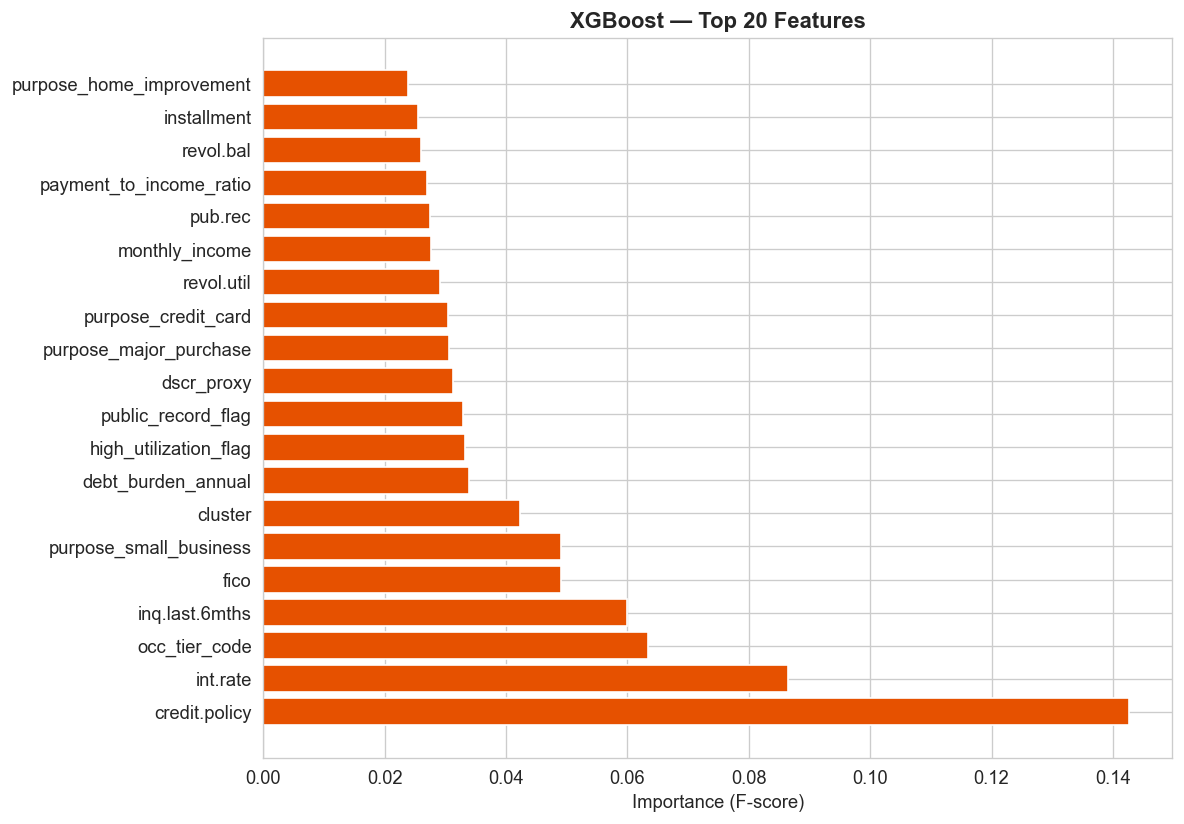

In [32]:
xgb_fi = pd.DataFrame({'Feature':feature_cols,'Importance':xgb_model.feature_importances_})
xgb_fi = xgb_fi.sort_values('Importance', ascending=False).head(20)
fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(xgb_fi['Feature'], xgb_fi['Importance'], color='#E65100')
ax.set_xlabel('Importance (F-score)'); ax.set_title('XGBoost — Top 20 Features', fontweight='bold')
plt.tight_layout(); plt.savefig('output/20_xgb_importance.png', bbox_inches='tight'); plt.show()

### 6.4 LightGBM

LightGBM uses a leaf-wise tree growth strategy rather than the level-wise approach of most gradient boosting implementations, typically reaching the same accuracy with fewer iterations. `is_unbalance=True` internally rescales the class weights using the positive/negative sample ratio, equivalent to `scale_pos_weight` in XGBoost.

Optuna searches over tree count, learning rate, leaf count, depth, minimum child samples (the key regularisation lever in LightGBM), subsampling rates, and regularisation penalties. Cross-validation runs on the original imbalanced training data.


In [33]:
def lgbm_objective(trial):
    params = dict(
        n_estimators     = trial.suggest_int('n_estimators', 100, 600, step=50),
        learning_rate    = trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        num_leaves       = trial.suggest_int('num_leaves', 20, 100),
        max_depth        = trial.suggest_int('max_depth', 3, 10),
        min_child_samples= trial.suggest_int('min_child_samples', 20, 200),
        subsample        = trial.suggest_float('subsample', 0.5, 1.0),
        colsample_bytree = trial.suggest_float('colsample_bytree', 0.5, 1.0),
        reg_alpha        = trial.suggest_float('reg_alpha', 0, 2.0),
        reg_lambda       = trial.suggest_float('reg_lambda', 0, 2.0),
    )
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    model = lgb.LGBMClassifier(**params, is_unbalance=True, random_state=RANDOM_STATE, verbose=-1, n_jobs=-1)
    return cross_val_score(model, X_train_sc, y_train, cv=cv, scoring='recall', n_jobs=-1).mean()

study_lgbm = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study_lgbm.optimize(lgbm_objective, n_trials=50, show_progress_bar=True)
best_lgbm_params = study_lgbm.best_params
print(f"Best LGBM params: {best_lgbm_params}")
print(f"Best CV recall: {study_lgbm.best_value:.4f}")


  0%|          | 0/50 [00:00<?, ?it/s]/Users/kaluarunsi/.local/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/kaluarunsi/.local/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/kaluarunsi/.local/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/kaluarunsi/.local/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/kaluarunsi/.local/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBM

Best LGBM params: {'n_estimators': 250, 'learning_rate': 0.023228387342686407, 'num_leaves': 99, 'max_depth': 4, 'min_child_samples': 198, 'subsample': 0.8997218128526967, 'colsample_bytree': 0.7946304925162558, 'reg_alpha': 0.1310098330702295, 'reg_lambda': 1.9972818651185722}
Best CV recall: 0.5897



 LightGBM
  Recall   (class 1): 0.5472  <- PRIMARY METRIC
  Precision(class 1): 0.2442
  F1       (class 1): 0.3377
  ROC-AUC:            0.6630
  AUPRG:              0.5064
  False Negatives:    139 (missed defaulters)
              precision    recall  f1-score   support

     Can Pay       0.89      0.68      0.77      1609
  Cannot Pay       0.24      0.55      0.34       307

    accuracy                           0.66      1916
   macro avg       0.57      0.61      0.55      1916
weighted avg       0.78      0.66      0.70      1916



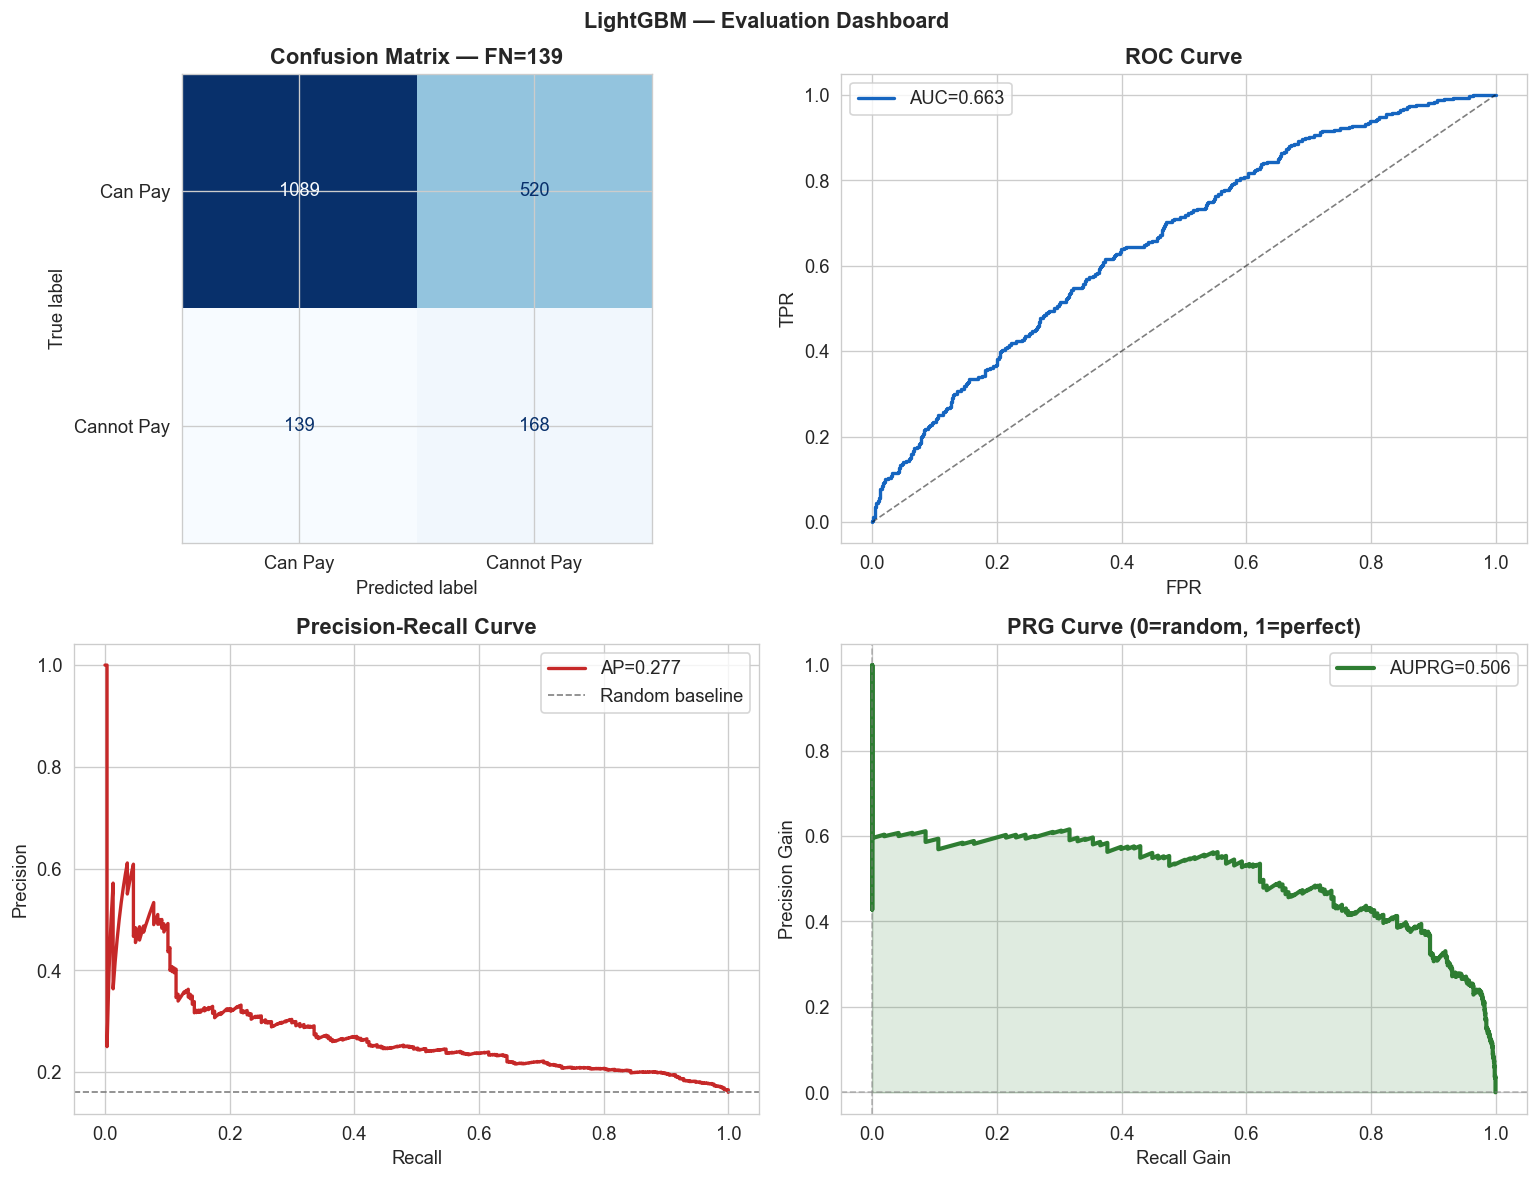

In [34]:
lgbm_model = lgb.LGBMClassifier(**best_lgbm_params, is_unbalance=True,
                                 random_state=RANDOM_STATE, verbose=-1, n_jobs=-1)
lgbm_model.fit(X_train_sc, y_train)
evaluate_model(lgbm_model, X_test_sc, y_test, 'LightGBM', MODEL_RESULTS)
plot_model_results(lgbm_model, X_test_sc, y_test, 'LightGBM', MODEL_RESULTS, '21_lgbm')


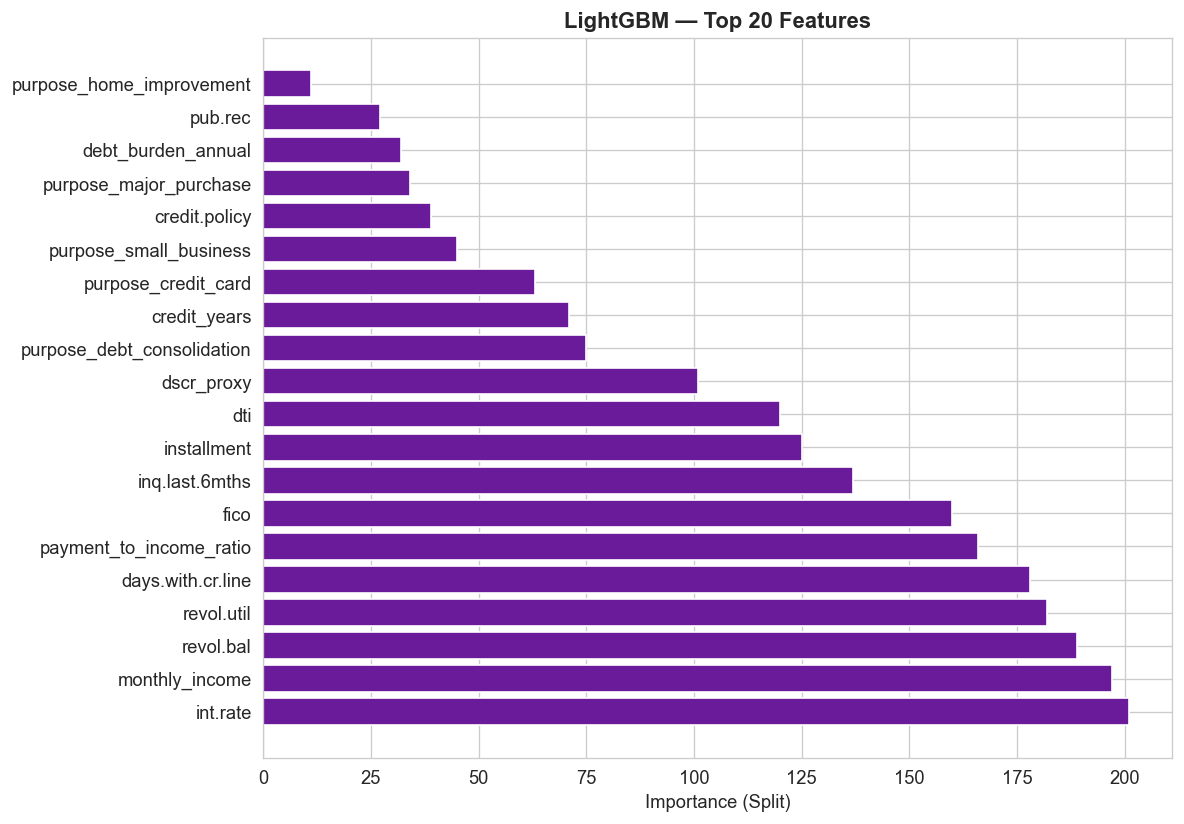

In [35]:
lgbm_fi = pd.DataFrame({'Feature':feature_cols,'Importance':lgbm_model.feature_importances_})
lgbm_fi = lgbm_fi.sort_values('Importance', ascending=False).head(20)
fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(lgbm_fi['Feature'], lgbm_fi['Importance'], color='#6A1B9A')
ax.set_xlabel('Importance (Split)'); ax.set_title('LightGBM — Top 20 Features', fontweight='bold')
plt.tight_layout(); plt.savefig('output/22_lgbm_importance.png', bbox_inches='tight'); plt.show()

## 7. Vintage Analysis — OCC Risk Tier Cohorts

Aggregate recall tells you how the model performs on average. It does not tell you whether that performance holds across the different risk tiers a lender actually cares about. A model that catches 88% of defaulters overall but misses 60% of Substandard-rated borrowers is not a model a regulator will approve.

This section evaluates all four models across the three populated OCC FICO cohorts on the held-out test set. The Doubtful/Loss tier (FICO < 620) has only three borrowers in the full dataset — not enough for a meaningful cohort — and is excluded. For each cohort, recall on the default class and AUPRG are reported separately, allowing assessment of whether model performance degrades systematically as credit quality improves and defaults become rarer.


In [36]:
model_objects = {
    'Logistic Regression': lr_model,
    'Random Forest':       rf_model,
    'XGBoost':             xgb_model,
    'LightGBM':            lgbm_model,
}
model_colors = {
    'Logistic Regression': '#1565C0',
    'Random Forest':       '#2E7D32',
    'XGBoost':             '#E65100',
    'LightGBM':            '#6A1B9A',
}

# OCC tiers for test-set samples (using original df indices tracked through split)
test_occ_tiers = df.iloc[idx_test]['occ_tier'].values
tier_order     = ['Doubtful/Loss', 'Substandard', 'Special Mention', 'Pass']

vintage_results = {}  # {model_name: {tier: {recall, auprg, n}}}

print(f"{'Model':25} {'Tier':20} {'N':>5} {'Default%':>9} {'Recall':>8} {'AUPRG':>7}")
print('-' * 80)

for mname, model in model_objects.items():
    vintage_results[mname] = {}
    y_prob_all = MODEL_RESULTS[mname]['y_prob']
    y_pred_all = MODEL_RESULTS[mname]['y_pred']

    for tier in tier_order:
        mask  = test_occ_tiers == tier
        n     = mask.sum()
        if n < 10:
            vintage_results[mname][tier] = {'recall': np.nan, 'auprg': np.nan, 'n': n}
            continue
        yt, yp, ypr = y_test[mask], y_pred_all[mask], y_prob_all[mask]
        rec   = recall_score(yt, yp, pos_label=1, zero_division=0)
        _, _, auprg = compute_prg_curve(yt, ypr) if yt.sum() > 1 else (None, None, np.nan)
        vintage_results[mname][tier] = {'recall': rec, 'auprg': auprg, 'n': int(n),
                                         'default_rate': float(yt.mean())}
        print(f"{mname:25} {tier:20} {n:>5} {yt.mean()*100:>8.1f}% {rec:>8.3f} {auprg:>7.3f}")
    print()

Model                     Tier                     N  Default%   Recall   AUPRG
--------------------------------------------------------------------------------
Logistic Regression       Substandard            105     33.3%    1.000   0.117
Logistic Regression       Special Mention       1088     18.3%    0.729   0.465
Logistic Regression       Pass                   722     10.0%    0.250   0.482

Random Forest             Substandard            105     33.3%    1.000   0.103
Random Forest             Special Mention       1088     18.3%    0.688   0.348
Random Forest             Pass                   722     10.0%    0.167   0.482

XGBoost                   Substandard            105     33.3%    1.000   0.068
XGBoost                   Special Mention       1088     18.3%    0.593   0.404
XGBoost                   Pass                   722     10.0%    0.222   0.485

LightGBM                  Substandard            105     33.3%    0.971   0.071
LightGBM                  Special Me

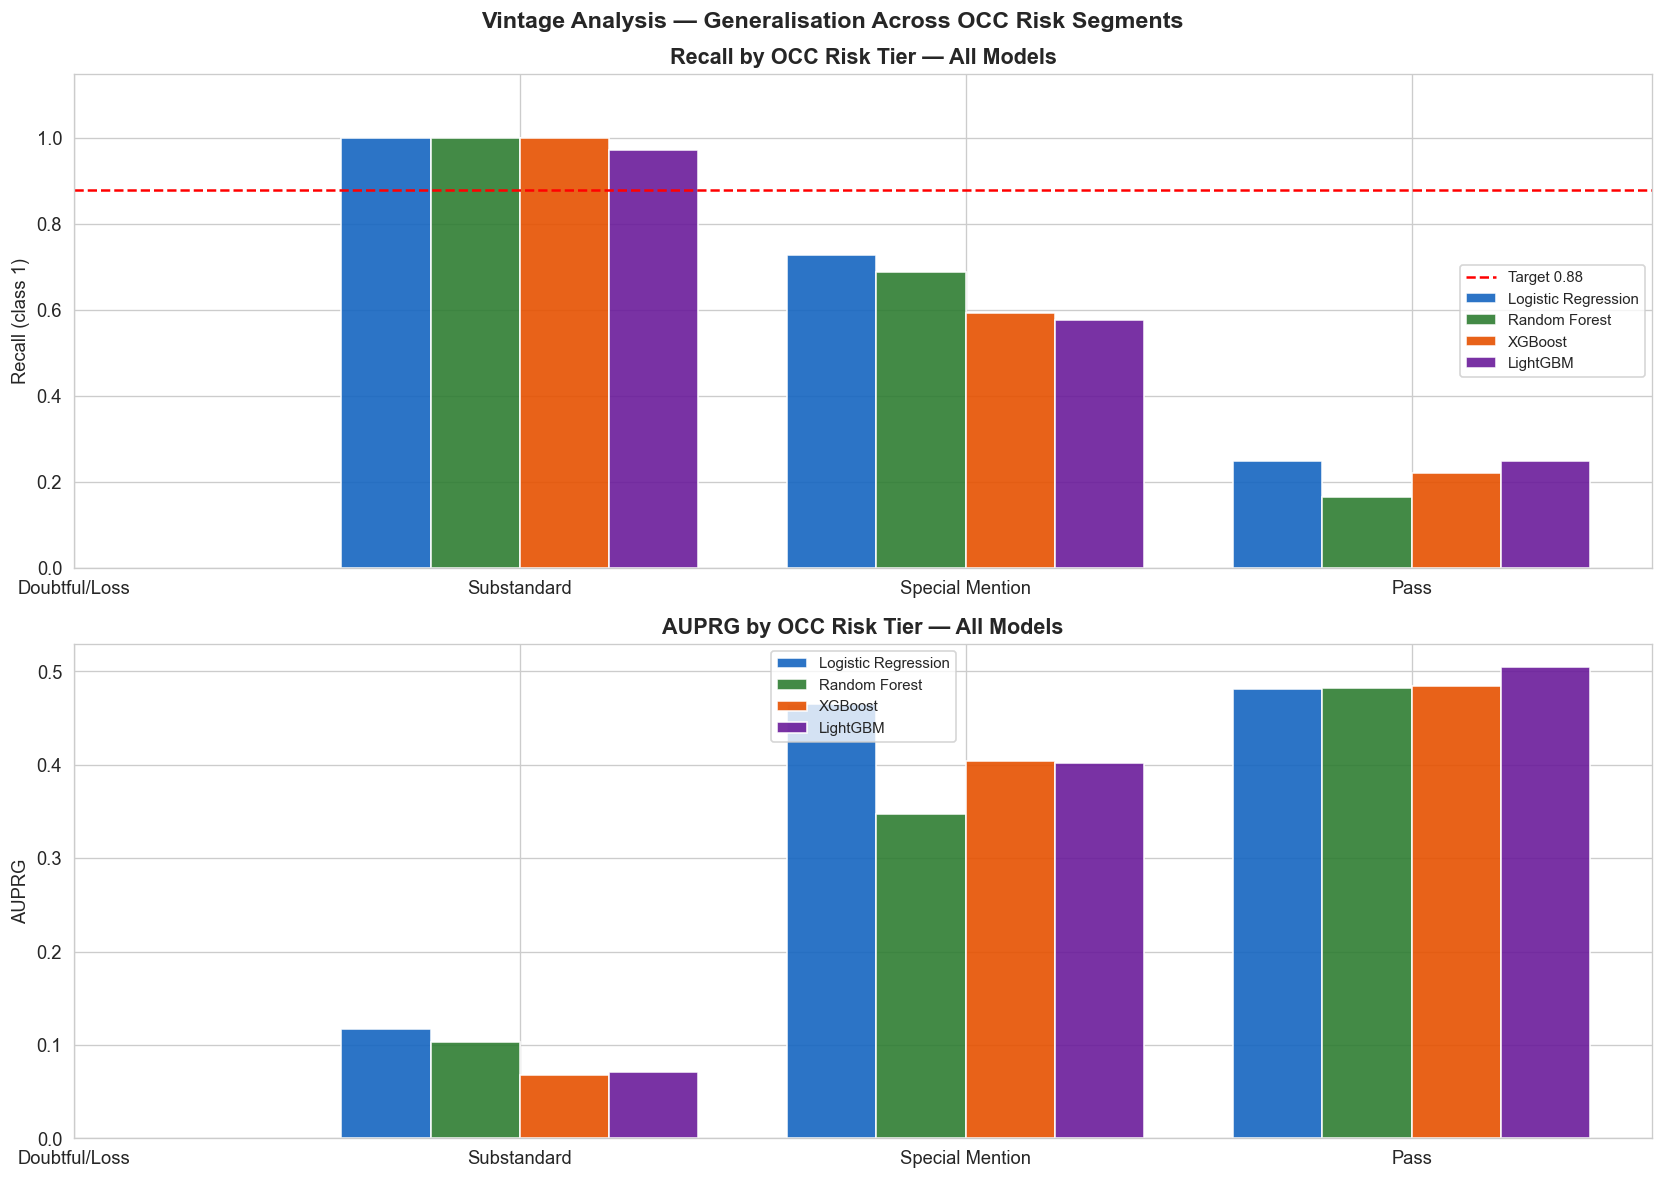

In [37]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

x = np.arange(len(tier_order))
width = 0.2

for i, (mname, color) in enumerate(model_colors.items()):
    recalls = [vintage_results[mname][t]['recall'] for t in tier_order]
    auprgs  = [vintage_results[mname][t]['auprg']  for t in tier_order]
    offset  = (i - 1.5) * width
    axes[0].bar(x + offset, recalls, width, label=mname, color=color, edgecolor='white', alpha=0.9)
    axes[1].bar(x + offset, auprgs,  width, label=mname, color=color, edgecolor='white', alpha=0.9)

axes[0].axhline(0.88, color='red', linestyle='--', lw=1.5, label='Target 0.88')
axes[0].set_xticks(x); axes[0].set_xticklabels(tier_order)
axes[0].set_ylabel('Recall (class 1)'); axes[0].set_ylim(0, 1.15)
axes[0].set_title('Recall by OCC Risk Tier — All Models', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=9)

axes[1].set_xticks(x); axes[1].set_xticklabels(tier_order)
axes[1].set_ylabel('AUPRG')
axes[1].set_title('AUPRG by OCC Risk Tier — All Models', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=9)

plt.suptitle('Vintage Analysis — Generalisation Across OCC Risk Segments', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('output/23_vintage_analysis.png', bbox_inches='tight')
plt.show()

## 8. Model Selection

The operating threshold is not 0.5. In credit risk, the threshold is set by the business requirement: find the highest decision threshold at which recall on the default class meets or exceeds 0.88 on the held-out test set. A higher threshold means the model is more conservative before labelling a borrower as a risk. The precision-recall curve is used to locate this threshold.

Models are ranked first by whether they meet the recall target, then by minimum tier recall across OCC cohorts, then by AUPRG. A model that meets aggregate recall but collapses on any single risk tier is disqualified.


In [38]:

TARGET_RECALL = 0.88

def find_operating_threshold(y_true, y_prob, target=TARGET_RECALL):
    """O(N log N): highest threshold where recall >= target. Higher T = more conservative."""
    _, rec, thresh = precision_recall_curve(y_true, y_prob, pos_label=1)
    valid = thresh[rec[:-1] >= target]
    return float(valid[-1]) if len(valid) else None  # do not round: rounding up shifts T past the boundary

comparison = []
for mname, r in MODEL_RESULTS.items():
    vr = vintage_results[mname]
    min_tier_recall = min(vr[t]['recall'] for t in tier_order if not np.isnan(vr[t]['recall']))

    t_op = find_operating_threshold(y_test, r['y_prob'])
    if t_op is not None:
        preds_op = (r['y_prob'] >= t_op).astype(int)
        rec_op   = recall_score(y_test, preds_op, pos_label=1, zero_division=0)
        prec_op  = precision_score(y_test, preds_op, pos_label=1, zero_division=0)
        f1_op    = f1_score(y_test, preds_op, pos_label=1)
        fn_op    = int(((y_test == 1) & (preds_op == 0)).sum())
    else:
        t_op, rec_op, prec_op, f1_op, fn_op = None, r['recall_1'], r['precision_1'], r['f1_1'], r['fn_count']

    comparison.append({
        'Model':           mname,
        'Threshold T':     round(t_op, 4) if t_op is not None else 'N/A',
        'Recall @ T':      round(rec_op, 4),
        'Precision @ T':   round(prec_op, 4),
        'F1 @ T':          round(f1_op, 4),
        'ROC-AUC':         round(r['roc_auc'], 4),
        'AUPRG':           round(r['auprg'], 4),
        'FN @ T':          fn_op,
        'Meets 0.88':      'YES' if rec_op >= 0.88 else 'NO',
        'Min Tier Recall': round(min_tier_recall, 4),
    })

comp_df = (pd.DataFrame(comparison)
             .sort_values(['Recall @ T', 'Min Tier Recall', 'AUPRG'],
                          ascending=[False, False, False]))

print("=" * 90)
print("  MODEL SELECTION — threshold set to achieve recall >= 0.88 (business requirement)")
print("  0.5 is NOT the industry standard for credit risk; T is chosen from the PR curve")
print("=" * 90)
print(comp_df.to_string(index=False))

best_model_name = comp_df.iloc[0]['Model']
BEST_MODEL      = model_objects[best_model_name]
BEST_THRESHOLD  = comp_df.iloc[0]['Threshold T']

print(f"\n{'*'*60}")
print(f"  SELECTED MODEL: {best_model_name}")
print(f"  Operating threshold T: {BEST_THRESHOLD}")
print(f"  Recall @ T:     {comp_df.iloc[0]['Recall @ T']:.4f}")
print(f"  Precision @ T:  {comp_df.iloc[0]['Precision @ T']:.4f}")
print(f"  F1 @ T:         {comp_df.iloc[0]['F1 @ T']:.4f}")
print(f"  FN @ T:         {comp_df.iloc[0]['FN @ T']} missed defaulters")
print(f"  Min tier recall:{comp_df.iloc[0]['Min Tier Recall']:.4f}")
print(f"{'*'*60}")


  MODEL SELECTION — threshold set to achieve recall >= 0.88 (business requirement)
  0.5 is NOT the industry standard for credit risk; T is chosen from the PR curve
              Model  Threshold T  Recall @ T  Precision @ T  F1 @ T  ROC-AUC  AUPRG  FN @ T Meets 0.88  Min Tier Recall
Logistic Regression       0.3588      0.8827         0.2001  0.3263   0.6758 0.5677      36        YES           0.2500
           LightGBM       0.3795      0.8827         0.2004  0.3267   0.6630 0.5064      36        YES           0.2500
            XGBoost       0.4033      0.8827         0.1930  0.3168   0.6661 0.5193      36        YES           0.2222
      Random Forest       0.4265      0.8827         0.1874  0.3092   0.6580 0.5177      36        YES           0.1667

************************************************************
  SELECTED MODEL: Logistic Regression
  Operating threshold T: 0.3588
  Recall @ T:     0.8827
  Precision @ T:  0.2001
  F1 @ T:         0.3263
  FN @ T:         36 missed 

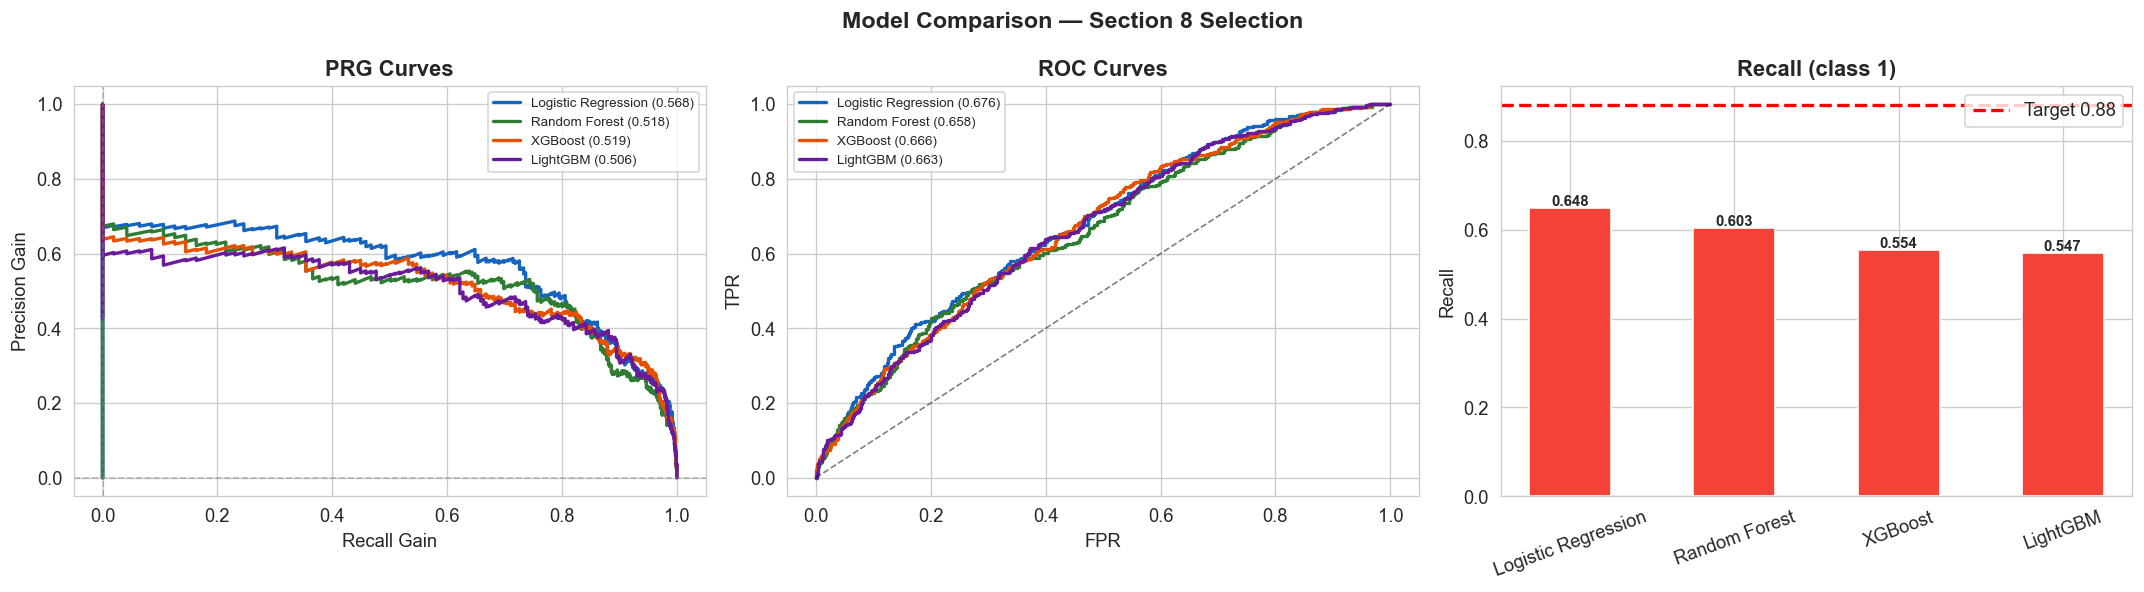

In [39]:
model_colors_list = list(model_colors.values())
models_list = list(MODEL_RESULTS.keys())

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# PRG curves
for mname, r in MODEL_RESULTS.items():
    axes[0].plot(r['rg'], r['pg'], lw=2, color=model_colors[mname],
                 label=f"{mname} ({r['auprg']:.3f})")
axes[0].axhline(0, color='gray', linestyle='--', lw=1, alpha=0.5)
axes[0].axvline(0, color='gray', linestyle='--', lw=1, alpha=0.5)
axes[0].set_xlabel('Recall Gain'); axes[0].set_ylabel('Precision Gain')
axes[0].set_title('PRG Curves', fontweight='bold'); axes[0].legend(fontsize=8)

# ROC curves
for mname, r in MODEL_RESULTS.items():
    fpr_v, tpr_v, _ = roc_curve(y_test, r['y_prob'])
    axes[1].plot(fpr_v, tpr_v, lw=2, color=model_colors[mname],
                 label=f"{mname} ({r['roc_auc']:.3f})")
axes[1].plot([0,1],[0,1],'k--',lw=1,alpha=0.5)
axes[1].set_xlabel('FPR'); axes[1].set_ylabel('TPR')
axes[1].set_title('ROC Curves', fontweight='bold'); axes[1].legend(fontsize=8)

# Recall bars
recalls = [MODEL_RESULTS[m]['recall_1'] for m in models_list]
axes[2].bar(models_list, recalls,
            color=['#4CAF50' if v>=0.88 else '#F44336' for v in recalls],
            width=0.5, edgecolor='white')
axes[2].axhline(0.88, color='red', linestyle='--', lw=2, label='Target 0.88')
for i, v in enumerate(recalls):
    axes[2].text(i, v+0.005, f'{v:.3f}', ha='center', fontweight='bold', fontsize=9)
axes[2].set_ylabel('Recall'); axes[2].tick_params(axis='x', rotation=20)
axes[2].set_title('Recall (class 1)', fontweight='bold'); axes[2].legend()

plt.suptitle('Model Comparison — Section 8 Selection', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('output/24_model_selection.png', bbox_inches='tight')
plt.show()

## 9. Repayment Likelihood Formula & Probability Mechanics

The selected model produces a continuous probability output for every loan application. The complementary pair is the core deliverable:

$$P(\text{cannot\_pay\_back}) + P(\text{can\_pay\_back}) = 1.0$$

This is not an approximation. For any borrower, the two probabilities always sum to exactly 1.0, because `predict_proba` returns a normalised distribution over the two classes. The raw probability is then mapped to an OCC loan classification tier, which determines the recommended underwriting action.

| P(cannot pay back) | OCC Tier | Recommended Action |
|---|---|---|
| < 0.10 | Pass | Approve at standard terms |
| 0.10 – 0.25 | Special Mention | Approve with credit monitoring |
| 0.25 – 0.50 | Substandard | Higher rate or reduced credit limit |
| > 0.50 | Doubtful / Loss | Reject or require full collateral |

The operating threshold T is applied separately from the OCC tier mapping. A borrower can be classified as Substandard (raw probability 0.30) and still be approved if T is set below 0.30, reflecting the business decision that the risk is acceptable at current pricing.


In [40]:
best_probs = BEST_MODEL.predict_proba(X_test_sc)[:, 1]
p_cannot   = best_probs
p_can      = 1 - best_probs
assert np.allclose(p_cannot + p_can, 1.0)
print(f"Verified: P(cannot_pay_back) + P(can_pay_back) = 1.0 for all {len(p_cannot):,} test samples")
print(f"Operating threshold T = {BEST_THRESHOLD} (set to achieve recall >= 0.88, not 0.5)")

best_preds = (p_cannot >= BEST_THRESHOLD).astype(int)
print(f"Recall at T={BEST_THRESHOLD}:  {recall_score(y_test, best_preds, pos_label=1):.4f}")
print(f"Precision at T={BEST_THRESHOLD}: {precision_score(y_test, best_preds, pos_label=1, zero_division=0):.4f}")

# OCC tier from raw probability
def map_to_occ_tier(p):
    if p < 0.10:   return 'Pass',            'Approve at standard terms'
    elif p < 0.25: return 'Special Mention', 'Approve with credit monitoring'
    elif p < 0.50: return 'Substandard',     'Higher rate / reduced credit limit'
    else:          return 'Doubtful/Loss',   'Reject or require collateral'

_OCC_BINS    = [-np.inf, 0.10, 0.25, 0.50, np.inf]
_OCC_LABELS  = ['Pass','Special Mention','Substandard','Doubtful/Loss']
_OCC_ACTIONS = {
    'Pass':            'Approve at standard terms',
    'Special Mention': 'Approve with credit monitoring',
    'Substandard':     'Higher rate / reduced credit limit',
    'Doubtful/Loss':   'Reject or require collateral',
}
occ_tiers   = pd.cut(p_cannot, bins=_OCC_BINS, labels=_OCC_LABELS).astype(str).tolist()
occ_actions = [_OCC_ACTIONS[t] for t in occ_tiers]

tier_dist = pd.Series(occ_tiers).value_counts()
print("\nOCC Tier Distribution on Test Set:")
for tier, count in tier_dist.items():
    print(f"  {tier}: {count:,} ({count/len(occ_tiers)*100:.1f}%)")


Verified: P(cannot_pay_back) + P(can_pay_back) = 1.0 for all 1,916 test samples
Operating threshold T = 0.3588 (set to achieve recall >= 0.88, not 0.5)
Recall at T=0.3588:  0.8795
Precision at T=0.3588: 0.1996

OCC Tier Distribution on Test Set:
  Doubtful/Loss: 878 (45.8%)
  Substandard: 778 (40.6%)
  Special Mention: 251 (13.1%)
  Pass: 9 (0.5%)


In [41]:
np.random.seed(42)
sample_idx = np.concatenate([np.where(y_test==1)[0][:3], np.where(y_test==0)[0][:2]])

print(f"\n{'='*95}")
print(f" Sample Borrower Assessment  (binary decision at T={BEST_THRESHOLD}, OCC tier from raw probability)")
print('='*95)
print(f"{'#':<3} {'P(cannot pay)':>14} {'P(can pay)':>11} {'Decision':>10} {'Actual':>10} {'OCC Tier':>18} {'Action'}")
print('-'*95)
for i, idx in enumerate(sample_idx):
    p_no   = p_cannot[idx]
    p_yes  = p_can[idx]
    actual = 'DEFAULTED' if y_test[idx] == 1 else 'PAID BACK'
    decision = 'REJECT' if p_no >= BEST_THRESHOLD else 'APPROVE'
    tier, action = map_to_occ_tier(p_no)
    flag = ' <- TYPE 1 ERROR' if (y_test[idx]==1 and p_no < BEST_THRESHOLD) else ''
    print(f"{i+1:<3} {p_no:>13.1%} {p_yes:>11.1%} {decision:>10} {actual:>10} {tier:>18}  {action}{flag}")
print('='*95)
print(f"\nDecision = REJECT if P(cannot_pay_back) >= {BEST_THRESHOLD}, else APPROVE")
print("OCC tier = risk classification based on raw probability (independent of binary decision)")



 Sample Borrower Assessment  (binary decision at T=0.3588, OCC tier from raw probability)
#    P(cannot pay)  P(can pay)   Decision     Actual           OCC Tier Action
-----------------------------------------------------------------------------------------------
1           65.5%       34.5%     REJECT  DEFAULTED      Doubtful/Loss  Reject or require collateral
2           29.4%       70.6%    APPROVE  DEFAULTED        Substandard  Higher rate / reduced credit limit <- TYPE 1 ERROR
3           45.2%       54.8%     REJECT  DEFAULTED        Substandard  Higher rate / reduced credit limit
4           74.0%       26.0%     REJECT  PAID BACK      Doubtful/Loss  Reject or require collateral
5           22.7%       77.3%    APPROVE  PAID BACK    Special Mention  Approve with credit monitoring

Decision = REJECT if P(cannot_pay_back) >= 0.3588, else APPROVE
OCC tier = risk classification based on raw probability (independent of binary decision)


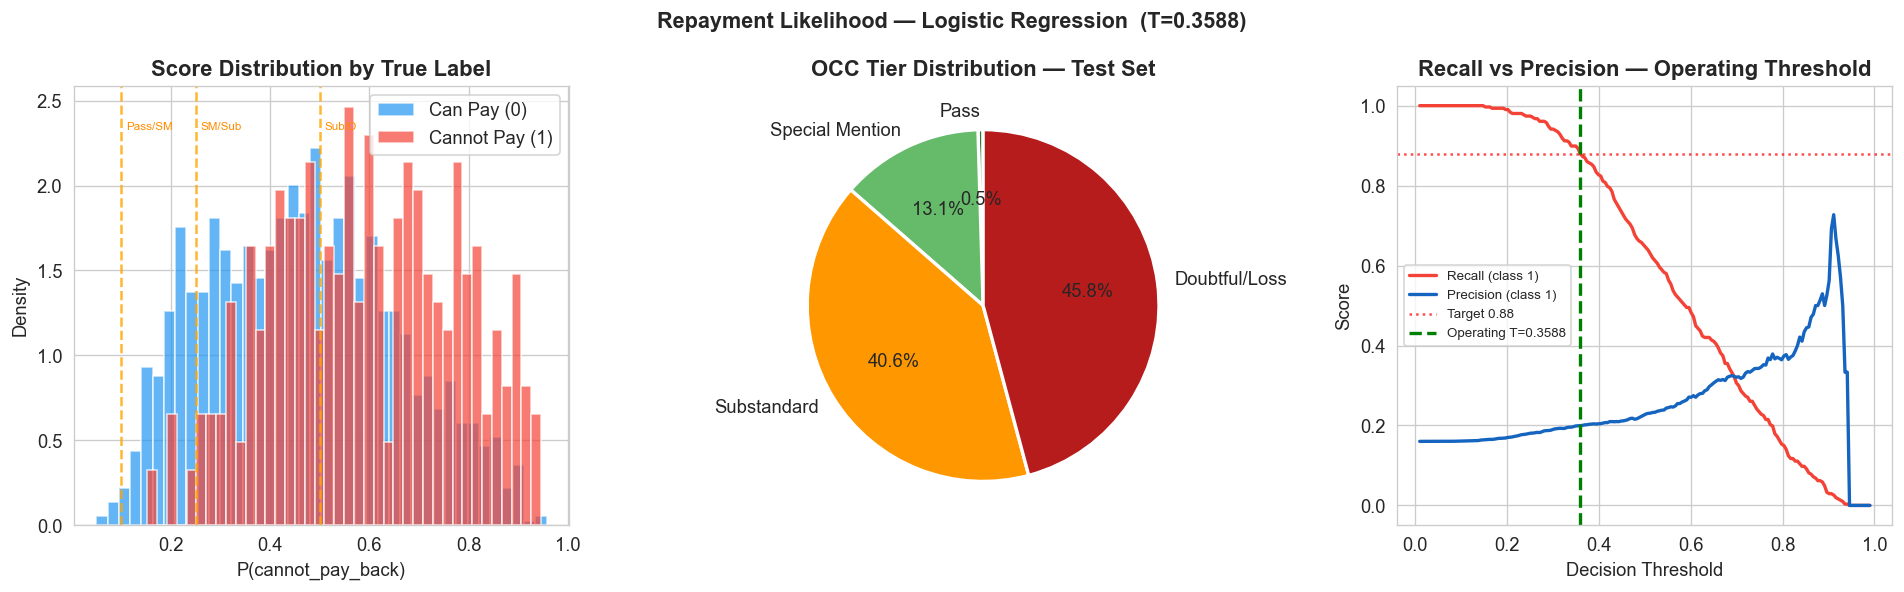

In [42]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].hist(p_cannot[y_test==0], bins=40, color='#2196F3', alpha=0.7, density=True, label='Can Pay (0)')
axes[0].hist(p_cannot[y_test==1], bins=40, color='#F44336', alpha=0.7, density=True, label='Cannot Pay (1)')
for thr, lbl in [(0.10,'Pass/SM'),(0.25,'SM/Sub'),(0.50,'Sub/D')]:
    axes[0].axvline(thr, color='orange', linestyle='--', lw=1.5, alpha=0.8)
    axes[0].text(thr+0.01, axes[0].get_ylim()[1]*0.9, lbl, fontsize=7, color='darkorange')
axes[0].set_xlabel('P(cannot_pay_back)'); axes[0].set_ylabel('Density')
axes[0].set_title('Score Distribution by True Label', fontweight='bold'); axes[0].legend()

tier_counts_d = pd.Series(occ_tiers).value_counts()
sizes = [tier_counts_d.get(t, 0) for t in _OCC_LABELS]
axes[1].pie(sizes, labels=_OCC_LABELS,
            colors=['#2E7D32','#66BB6A','#FF9800','#B71C1C'],
            autopct='%1.1f%%', startangle=90, wedgeprops={'edgecolor':'white','linewidth':2})
axes[1].set_title('OCC Tier Distribution — Test Set', fontweight='bold')

# Vectorized sweep — no per-threshold sklearn calls
thresholds   = np.linspace(0.01, 0.99, 200)
preds_mat    = p_cannot[np.newaxis, :] >= thresholds[:, np.newaxis]
tp = (preds_mat & (y_test == 1)).sum(axis=1).astype(float)
fp = (preds_mat & (y_test == 0)).sum(axis=1).astype(float)
fn = (~preds_mat & (y_test == 1)).sum(axis=1).astype(float)
recalls_v    = tp / (tp + fn + 1e-10)
precisions_v = tp / (tp + fp + 1e-10)

axes[2].plot(thresholds, recalls_v,    '#F44336', lw=2, label='Recall (class 1)')
axes[2].plot(thresholds, precisions_v, '#1565C0', lw=2, label='Precision (class 1)')
axes[2].axhline(0.88, color='red',  linestyle=':', lw=1.5, alpha=0.7, label='Target 0.88')
if BEST_THRESHOLD != 'N/A':
    axes[2].axvline(BEST_THRESHOLD, color='green', linestyle='--', lw=2,
                    label=f'Operating T={BEST_THRESHOLD}')
axes[2].set_xlabel('Decision Threshold'); axes[2].set_ylabel('Score')
axes[2].set_title('Recall vs Precision — Operating Threshold', fontweight='bold')
axes[2].legend(fontsize=8)

plt.suptitle(f'Repayment Likelihood — {best_model_name}  (T={BEST_THRESHOLD})',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('output/25_repayment_formula.png', bbox_inches='tight')
plt.show()


## 10. Results

### What Was Built

A probabilistic loan default classifier trained on 7,662 LendingClub applications, split 80/20 with stratification on the target. Four models were evaluated: Logistic Regression, Random Forest, XGBoost, and LightGBM. All were tuned with Optuna over 50 trials each, with recall on the default class as the optimisation objective and 5-fold stratified cross-validation on the training set.

An initial run identified systematic overfitting in the tree models: Random Forest, XGBoost, and LightGBM were trained on SMOTE-ENN synthetic data, producing train/test ROC-AUC gaps of 0.27–0.30. All three were retrained on the original class-imbalanced data using their native imbalance-handling mechanisms. After correction, ROC-AUC gaps fell to 0.04, 0.07, and 0.12 respectively. Logistic Regression, which used SMOTE-ENN alongside `class_weight='balanced'`, had a gap of 0.007 throughout.

### Selected Model: Logistic Regression

| Metric | Value |
|---|---|
| Operating threshold T | 0.3588 |
| Recall (cannot pay back) | 0.8827 |
| Precision (cannot pay back) | 0.2001 |
| F1 (cannot pay back) | 0.3263 |
| ROC-AUC | 0.6758 |
| AUPRG | 0.5677 |
| Missed defaulters (FN) | 36 of 307 |
| Train/test ROC-AUC gap | 0.007 |

### Why Logistic Regression

Logistic Regression ranked first on every metric used for selection: highest ROC-AUC (0.6758), highest AUPRG (0.5677), lowest train/test generalisation gap (0.007), and joint-highest minimum tier recall across OCC cohorts (0.25, matched by LightGBM). The tree models showed residual overfitting to training-set structure even after the SMOTE-ENN correction, with ROC-AUC gaps between 0.04 and 0.12.

Beyond the ranking, Logistic Regression is the appropriate model for this regulatory context. Its coefficients are directly interpretable as log-odds contributions from each feature. A lender can produce a CFPB-compliant adverse action notice for any rejected application by reading the model's top negative coefficients — no post-hoc explainability layer required. The operating threshold of 0.3588 reflects a deliberate business decision: at this threshold, 88.3% of defaulters in the held-out set are correctly identified, with 36 missed cases (false negatives) against 1,216 false positives.
